# Measurements — Born rule, collapse, sampling and shot noise

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 3 — The matrix-free engine*

## 1. Introduction and motivation

A simulator hands us the full wave function: $2^N$ complex amplitudes, to sixteen digits. **A laboratory never does.**
What an experiment on $N$ spins (trapped ions, superconducting qubits, Rydberg atoms, cold atoms under a quantum-gas
microscope) returns is a *click pattern*: one string of $N$ bits per run of the experiment — a "shot". Expectation
values are then **estimated** by averaging over many shots and come with statistical error bars that shrink only like
$1/\sqrt{\text{shots}}$. If we want our simulations to say something about experiments — how many shots are needed to see an
effect, whether a variational algorithm survives its own measurement noise, how a protocol with feedback behaves —
we have to simulate the measurement process itself.

Measurement is also much more than "reading out the answer at the end":

* it is the only **non-unitary, random** element of quantum mechanics — the state *changes* (collapses) when we look;
* measuring *part* of an entangled system changes the state of the rest: this can **destroy** entanglement (a cat state dies
  when one spin is observed) or **create** it between distant spins (measurement-based quantum computing, entanglement swapping);
* **mid-circuit measurements with feedback** are the core of teleportation, quantum error correction, qubit reset and reuse,
  quantum reservoir computing, and of measurement-induced phase transitions — all topics of later chapters of these notes.

**What we will do.** We derive the Born rule and the collapse for one spin out of $N$ directly on the state *tensor*
(Sections 3–4), turn them into a function `measure_qubit` that contains **no Python branching on random values** and can therefore
be compiled with `jax.jit` and batched over thousands of shots with `jax.vmap` (Sections 5–8), add the active `reset_qubit`
(Section 7), study what a measurement does to the *other* spins (Section 9), sample complete bit strings
(`sample_bitstrings`, Section 10), do **shot-noise statistics with error bars** (Section 11), look at the correlations of a
Bell pair measured along different axes (Section 12), and finally put measurements *inside* compiled loops: the quantum
Zeno effect and entanglement created by measurement (Section 13). Section 14 measures the cost.

### What you will learn

*Physics*

* the measurement postulate for a subsystem: Born probabilities from the reduced density matrix, collapse by projection;
* measuring $X$, $Y$ or along any axis = rotate, measure $Z$, rotate back;
* measurement back-action on entangled states: GHZ versus W; unread measurement = dephasing; reset as a quantum channel;
* shot noise, standard errors, the central limit theorem at work; Bell correlations $E(\theta)=\cos\theta$; the quantum Zeno effect.

*Numerical methods*

* sampling from a discrete distribution three ways (threshold on a uniform number, Gumbel-max / `categorical`, inverse CDF) and their costs;
* sequential (chain-rule) sampling versus joint sampling of bit strings;
* estimators with error bars, $\chi^2$ and $z$-score sanity checks for stochastic code.

*Implementation practice*

* explicit PRNG keys: splitting, reproducibility, one key per random decision;
* replacing `if random < p:` by `jnp.where` so that the code survives `jit`, `vmap` and `lax.scan`;
* `vmap` over keys = many shots; `lax.scan` with keys as the scanned input = repeated measurements in time.

### Prerequisites
* [01 — JAX from scratch](../ch01_computational_toolbox/01_jax_from_scratch.ipynb): `jit`, `vmap`, `lax.scan`, PRNG keys;
* [05 — matrix-free operators](05_matrix_free_operators.ipynb): state tensors and `apply_gate`;
* [06 — states, observables, entanglement](06_states_observables_entanglement.ipynb): reduced density matrices `rdm`, expectation values, entanglement entropy;
* helpful but not required: [07 — density matrices and quantum channels](07_density_matrices_and_quantum_channels.ipynb).

**Conventions**: spin/qubit $q$ = tensor axis $q$; $|0\rangle=(1,0)^T$ is the $+1$ eigenstate of $Z$ ("up"), $|1\rangle$ the $-1$ eigenstate;
measurement **outcome $m\in\{0,1\}$ means eigenvalue $(-1)^m$**; bit strings are written $s_0s_1\dots s_{N-1}$ with spin 0 leftmost (most significant bit of the flat index).

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels: enough for N<=26 (pure) / N<=13 (DM)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

From earlier notebooks we reuse the state constructors, `apply_gate` (one einsum that applies a small matrix to chosen axes of the
state tensor), the reduced density matrix `rdm`, expectation values and the entanglement entropy. The measurement functions themselves
are **not** in this recap — we build them from scratch below.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
XX = jnp.kron(X, X)
YY = jnp.kron(Y, Y)
ZZ = jnp.kron(Z, Z)
def rx(theta):
    """Rotation about x:  Rx(theta) = exp(-i theta X/2) = cos(theta/2) 1 - i sin(theta/2) X.

    Derivation: for any operator with P^2 = 1 the exponential series splits into even/odd
    parts,  exp(-i a P) = cos(a) 1 - i sin(a) P.   Here a = theta/2.
    `theta` may be a traced JAX scalar, so the gate is differentiable (jax.grad) and jit-able.
    """
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -1j * s], [-1j * s, c]], dtype=CDTYPE)

def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def cluster_state(N, periodic=False):
    """1D cluster (graph) state: |+>^N followed by CZ on every bond.  Stabilisers K_i = Z_{i-1} X_i Z_{i+1}."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    if periodic and N > 2:
        psi = apply_gate(psi, CZ, [N - 1, 0])
    return psi

def bell_state(kind="phi+"):
    """The four Bell states as (2,2) tensors: phi+- = (|00> +- |11>)/sqrt2, psi+- = (|01> +- |10>)/sqrt2."""
    a = 1 / np.sqrt(2)
    v = {"phi+": [a, 0, 0, a], "phi-": [a, 0, 0, -a], "psi+": [0, a, a, 0], "psi-": [0, a, -a, 0]}[kind]
    return jnp.array(v, dtype=CDTYPE).reshape(2, 2)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def expect_local(psi, O, qubits):
    """<psi| O_qubits |psi> for a k-local operator O (2^k x 2^k matrix).

    MATH   <O> = Tr(rho_A O)  with A = `qubits`: a local observable only sees the local state.
    Cost O(2^N) for the RDM + O(4^k) for the small trace.  One RDM serves ALL observables on A
    (e.g. <X>,<Y>,<Z> from a single 2x2 matrix).
    """
    return jnp.real(jnp.trace(rdm(psi, qubits) @ jnp.asarray(O, dtype=CDTYPE)))

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 5. State characteristics: entropies, fidelity, negativity
# ----------------------------------------------------------------------------
def schmidt_values(psi, subsystem):
    """Schmidt coefficients of the bipartition A|B with A = `subsystem`.

    MATH   Group the tensor axes into a matrix  M[(a),(b)] = psi[a,b]  of shape (2^|A|, 2^|B|).
           Its SVD  M = U diag(lambda) V^dag  IS the Schmidt decomposition
               |psi> = sum_k lambda_k |u_k>_A |v_k>_B ,     rho_A has eigenvalues lambda_k^2.
    IMPLEMENTATION   transpose (A axes first) -> reshape -> svd.   No density matrix needed.
    """
    A = tuple(int(q) for q in subsystem)
    B = tuple(q for q in range(psi.ndim) if q not in A)
    M = jnp.transpose(psi, A + B).reshape(2 ** len(A), -1)
    return jnp.linalg.svd(M, compute_uv=False)

def entanglement_entropy(psi, subsystem, base=2.0):
    """Entanglement entropy S_A = -sum_k p_k log p_k with p_k = lambda_k^2 (squared Schmidt values).
    Product state: 0.  Bell/GHZ across any cut: 1 bit.  Random state: ~ |A| - 1/(2 ln2) 2^{|A|-|B|} (Page)."""
    p = jnp.clip(schmidt_values(psi, subsystem) ** 2, 1e-16, None)
    return -jnp.sum(p * jnp.log(p)) / jnp.log(base)


# ----------------------------------------------------------------------------
# 8. Hamiltonians as lists of local terms;  H|psi>  matrix-free
# ----------------------------------------------------------------------------
def heisenberg_terms(N, Jxx=1.0, Jyy=1.0, Jzz=1.0, hx=0.0, hy=0.0, hz=0.0, periodic=False, bonds=None):
    """Spin-1/2 Hamiltonian in Pauli convention
        H = sum_<ij> (Jxx X_i X_j + Jyy Y_i Y_j + Jzz Z_i Z_j) + sum_i (hx X_i + hy Y_i + hz Z_i)
    returned as a LIST of local terms [(qubits, small_matrix), ...]  -- this list *is* our Hamiltonian.
      Heisenberg: Jxx=Jyy=Jzz     XXZ: Jxx=Jyy!=Jzz     XY: Jzz=0     TFIM: only Jzz and hx.
    `bonds` overrides the default open chain (any graph: ladders, 2D lattices, all-to-all, ...)."""
    if bonds is None:
        bonds = [(i, i + 1) for i in range(N - 1)] + ([(N - 1, 0)] if periodic and N > 2 else [])
    terms = [((i, j), Jxx * XX + Jyy * YY + Jzz * ZZ) for (i, j) in bonds]
    if hx != 0 or hy != 0 or hz != 0:
        terms += [((i,), hx * X + hy * Y + hz * Z) for i in range(N)]
    return terms

def apply_hamiltonian(terms, psi):
    """H|psi> = sum_k h_k|psi>, every term applied with `apply_gate` (h_k is Hermitian, not unitary --
    the einsum does not care).  Cost O(#terms * 2^N).  This matrix-vector product is ALL that Lanczos,
    Chebyshev and Krylov methods need, which is why they scale to N ~ 25-30."""
    out = jnp.zeros_like(psi)
    for qubits, h in terms:
        out = out + apply_gate(psi, h, qubits)
    return out

def energy(terms, psi):
    """<psi|H|psi> = Re <psi | (H psi)>."""
    return jnp.real(jnp.vdot(psi, apply_hamiltonian(terms, psi)))


# ----------------------------------------------------------------------------
# 9. Time evolution: TEBD / Trotter-Suzuki, Chebyshev, Krylov, exact
# ----------------------------------------------------------------------------
def lanczos(matvec, v0, m=60, reorth=True):
    """m-step Lanczos iteration: orthonormal basis V of the Krylov space span{v, Hv, H^2 v, ...}
    in which H is TRIDIAGONAL:   T = V^dag H V = tridiag(beta, alpha, beta).

    Recurrence     w = H v_j - alpha_j v_j - beta_{j-1} v_{j-1},   alpha_j = <v_j|H|v_j>,   beta_j = ||w||.
    `reorth=True`  re-orthogonalises against all previous vectors (cures the loss of orthogonality of
                   floating-point Lanczos at the price of O(m^2) inner products).
    Only `matvec` (H|psi>) is needed -> matrix-free.  Returns (alphas, betas, V[m, 2,..,2]).
    """
    v = v0 / jnp.linalg.norm(v0)
    V, alphas, betas = [v], [], []
    w = matvec(v)
    for j in range(m):
        a = jnp.real(jnp.vdot(V[j], w))
        alphas.append(a)
        w = w - a * V[j] - (betas[-1] * V[j - 1] if j > 0 else 0.0)
        if reorth:
            for u in V:
                w = w - jnp.vdot(u, w) * u
        b = jnp.linalg.norm(w)
        if j == m - 1 or float(b) < 1e-12:
            break
        betas.append(b)
        V.append(w / b)
        w = matvec(V[-1])
    return np.array(alphas, dtype=float), np.array(betas, dtype=float), jnp.stack(V)

def lanczos_ground_state(terms, N, m=80, key=None, restarts=3):
    """Ground state (E_0, |psi_0>) from restarted Lanczos: diagonalise the small T, map its lowest
    eigenvector back with V, use it as the next start vector.  Extremal eigenvalues converge first."""
    key = jax.random.PRNGKey(0) if key is None else key
    v = haar_state(key, N)
    mv = jax.jit(lambda p: apply_hamiltonian(terms, p))
    E = None
    for _ in range(restarts):
        a, b, V = lanczos(mv, v, m)
        w, S_ = np.linalg.eigh(np.diag(a) + np.diag(b, 1) + np.diag(b, -1))
        v = jnp.tensordot(jnp.asarray(S_[:, 0], dtype=CDTYPE), V, axes=1)
        v = v / jnp.linalg.norm(v)
        E = w[0]
    return float(E), v


In [3]:
# ==============================================================================
# PLOT STYLE + small helpers
# ==============================================================================
import itertools

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def kron_chain(mats):
    """Dense reference: mats[0] (x) mats[1] (x) ...  -- builds a 2^N x 2^N matrix, VALIDATION ONLY."""
    out = np.eye(1, dtype=complex)
    for m in mats:
        out = np.kron(out, np.asarray(m))
    return out


def max_abs(a):
    """Largest absolute entry, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


def bits_to_str(bits):
    return "".join(str(int(b)) for b in np.asarray(bits))

## 3. Theory: the measurement postulate for one spin out of $N$

**The postulate** (as in your quantum mechanics course). An observable is a Hermitian operator with spectral decomposition
$O=\sum_m\lambda_m\Pi_m$, where $\Pi_m$ projects onto the eigenspace of the eigenvalue $\lambda_m$
($\Pi_m\Pi_{m'}=\delta_{mm'}\Pi_m$, $\sum_m\Pi_m=\mathbb 1$). Measuring $O$ on the state $|\psi\rangle$

1. gives the result $\lambda_m$ with probability $p(m)=\langle\psi|\Pi_m|\psi\rangle=\|\Pi_m|\psi\rangle\|^2$ (**Born rule**);
2. leaves the system in the state $|\psi_m\rangle=\Pi_m|\psi\rangle/\sqrt{p(m)}$ (**collapse**, projection postulate).

**One spin out of many.** We measure $Z_q$ on spin $q$ of an $N$-spin register. The eigenvalues are $\pm1=(-1)^m$ and the projectors are

$$\Pi_m=\mathbb 1\otimes\dots\otimes\underbrace{|m\rangle\langle m|}_{\text{spin }q}\otimes\dots\otimes\mathbb 1,\qquad P_0=|0\rangle\langle0|=\begin{pmatrix}1&0\\0&0\end{pmatrix},\quad P_1=|1\rangle\langle1|=\begin{pmatrix}0&0\\0&1\end{pmatrix}.$$

$\Pi_m$ is highly degenerate: it projects onto a $2^{N-1}$-dimensional subspace, so the post-measurement state is in general *still a superposition* (and may still be entangled).
In tensor language $\Pi_m$ simply **keeps the slice $s_q=m$ of the state tensor and zeroes the other slice**:

$$(\Pi_m\psi)[s_0,\dots,s_q,\dots,s_{N-1}]=\delta_{s_q,m}\;\psi[s_0,\dots,s_q,\dots,s_{N-1}].$$

Hence the Born probability is the total weight of that slice,

$$p(m)=\sum_{s\,:\,s_q=m}|\psi[s_0,\dots,s_{N-1}]|^2=\big(\rho_q\big)_{mm},\qquad(1)$$

which we recognise as a diagonal element of the single-spin reduced density matrix $\rho_q[a,a']=\sum_{\rm rest}\psi[..a..]\psi^*[..a'..]$ of notebook 06.
This is general: **the statistics of any measurement on a subsystem depend only on its reduced density matrix.**

### 3.1 What the postulate does and does not say

Three qualifications belong to the statement above; all three come back later in these notes.

* **Projective, not general.** The postulate as written is the *projective* (von Neumann) case. The general measurement
  postulate replaces the projectors by any family of operators $M_m$ with $\sum_mM_m^\dagger M_m=\mathbb 1$, giving
  $p(m)=\langle\psi\vert M_m^\dagger M_m\vert\psi\rangle$ and $\vert\psi_m\rangle=M_m\vert\psi\rangle/\sqrt{p(m)}$;
  projective measurements are the special case $M_m=\Pi_m$ with $\Pi_m^\dagger=\Pi_m=\Pi_m^2$. The $M_m$ are the Kraus
  operators of [notebook 07](07_density_matrices_and_quantum_channels.ipynb). A photodetector that absorbs the photon it
  counts is a measurement of this general kind and is *not* described by the projection rule above.
* **The post-measurement state is a second assumption.** For a degenerate eigenvalue, $\vert\psi_m\rangle\propto\Pi_m\vert\psi\rangle$
  is the *Lüders rule*: the state is disturbed as little as the outcome allows. It is what an ideal repeatable apparatus does —
  measure twice in a row and get the same answer — and it is the rule we implement; a real apparatus can reproduce the Born
  probabilities and still leave a different state behind.
* **Selective versus non-selective.** The update is the state we assign *given* that the outcome $m$ has been read. If the
  measurement happens but the result is discarded, the correct description is the average $\sum_mp(m)\vert\psi_m\rangle\langle\psi_m\vert$
  — a density matrix, not a state vector. Section 9.2 computes it and identifies it with a noise channel. "Collapse" is the
  name of this update rule; the formalism prescribes it without saying what brings it about, which is the measurement problem.

### 3.2 The algorithm

The algorithm has three steps: (i) compute $p(0)$ from Eq. (1); (ii) draw the outcome $m$ at random with these probabilities; (iii) apply the $2\times2$ projector $P_m$ to axis $q$
— this is just `apply_gate` with a non-unitary matrix — and renormalise. Cost: $O(2^N)$ per measurement, no large matrix anywhere.

## 4. From formula to code, step 1: Born probabilities and collapse (deterministic parts)

For $N=3$ and $q=1$ Eq. (1) reads $p(b)=\sum_{a,c}\psi[a,b,c]\psi^*[a,b,c]$: the letter $b$ is kept, $a$ and $c$ are summed. As an einsum: `"abc,abc->b"`.
We compute the probabilities in three independent ways — slice weights (the einsum), the diagonal of the RDM, and the textbook expectation value of the
$8\times8$ projector built with Kronecker products — and then the collapsed state, by hand with `"Bb,abc->aBc"` (the projector contracted with the middle axis), against the dense projector.

In [4]:
# ==============================================================================
# STEP 1: p(m) and the collapsed state for N = 3, q = 1 -- by hand, three ways
# ==============================================================================
psi3 = haar_state(jax.random.PRNGKey(3), 3)                     # a generic state: no symmetry hides a bug
v3 = np.asarray(psi3).reshape(-1)                               # the same state as a length-8 vector (dense reference)

p_slices = jnp.real(jnp.einsum("abc,abc->b", psi3, psi3.conj()))                # (i)   weight of the slices s_1 = 0, 1
p_rdm = jnp.real(jnp.diag(rdm(psi3, (1,))))                                     # (ii)  diagonal of the 1-spin RDM
Pi = [kron_chain([I2, P, I2]) for P in (P0, P1)]                                # (iii) dense 8x8 projectors 1 (x) P_m (x) 1
p_dense = np.array([np.real(v3.conj() @ Pi_m @ v3) for Pi_m in Pi])
print("p(m) from slices   :", np.asarray(p_slices))
print("p(m) from the RDM  :", np.asarray(p_rdm))
print("p(m) dense <Pi_m>  :", p_dense, "  sum =", p_dense.sum())
assert max_abs(p_slices - p_dense) < TOL and max_abs(p_rdm - p_dense) < TOL

for m, P in enumerate((P0, P1)):
    phi = jnp.einsum("Bb,abc->aBc", P, psi3)                    # projector on the middle axis (what apply_gate does)
    phi = phi / jnp.linalg.norm(phi)                            # renormalise: divide by sqrt(p(m))
    ref = Pi[m] @ v3 / np.sqrt(p_dense[m])
    err = max_abs(phi.reshape(-1) - ref)
    print(f"CHECKPOINT collapse on outcome {m}: max error vs dense projector = {err:.1e};  "
          f"weight left in the other slice = {float(jnp.sum(jnp.abs(phi[:, 1 - m, :]) ** 2)):.1e}")
    assert err < TOL

p(m) from slices   : [0.48316216 0.51683784]
p(m) from the RDM  : [0.48316216 0.51683784]
p(m) dense <Pi_m>  : [0.48316216 0.51683784]   sum = 1.0


CHECKPOINT collapse on outcome 0: max error vs dense projector = 1.2e-16;  weight left in the other slice = 0.0e+00
CHECKPOINT collapse on outcome 1: max error vs dense projector = 1.1e-16;  weight left in the other slice = 0.0e+00


The three routes to $p(m)$ agree and sum to one; after the projection the "wrong" slice of the tensor is exactly empty and the state matches the dense textbook result.
The norm of the projected tensor *before* renormalisation is $\sqrt{p(m)}$ — a useful fact: probabilities can always be read off from norms of projected states.

## 5. Step 2: the random outcome — explicit keys and no Python `if`

**Drawing the outcome.** A two-outcome random variable with $P(m{=}0)=p_0$ is obtained from one uniform random number $u\in[0,1)$: set $m=0$ if $u<p_0$ and $m=1$ otherwise.

**Randomness in JAX** (recap of notebook 01). There is no hidden global random state. Every random function takes an explicit **key**; the same key always produces the same number.
To get independent numbers we `split` a key into new ones and *never reuse a key*. This looks pedantic, but it is exactly what makes a stochastic simulation reproducible, parallelisable
(each shot gets its own key — no ordering issues) and compatible with `jit`.

**The NumPy-style version** of a measurement is what everybody writes first:
```python
if u < p0:  project with P0   else:  project with P1
```
It works in eager mode. But under `jax.jit` (or `vmap`) the function is *traced*: JAX runs it once with abstract placeholders ("tracers") instead of numbers in order to record the computation.
A tracer has no value, so Python cannot decide the `if` — the cell below shows the resulting error.

In [5]:
# ==============================================================================
# STEP 2a: the naive version with a Python branch -- fine eagerly, breaks under jit
# ==============================================================================
def measure_z_naive(key, psi, q):
    """Z measurement of spin q with a Python `if` on the random number (DO NOT use: not jit/vmap-able)."""
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    u = jax.random.uniform(key)
    if u < p0:                                   # <-- Python control flow on a random VALUE
        outcome, proj = 0, P0
    else:
        outcome, proj = 1, P1
    psi = apply_gate(psi, proj, [q])
    return outcome, psi / jnp.linalg.norm(psi)


key = jax.random.PRNGKey(42)
print("eager call works    : outcome =", measure_z_naive(key, psi3, 1)[0])
try:
    jax.jit(measure_z_naive, static_argnums=2)(key, psi3, 1)
except Exception as err:                         # jax.errors.TracerBoolConversionError
    print("under jit it fails  :", type(err).__name__)

eager call works    : outcome = 0
under jit it fails  : TracerBoolConversionError


**The cure: compute both options, select with arithmetic.** The outcome is the *array expression* `(u >= p0)` cast to an integer, and the projector is selected with
`jnp.where(outcome == 0, P0, P1)` — a $2\times2$ array whose entries depend on the traced outcome. There is no branch any more: the compiled program is the same for both outcomes, only the numbers differ.
(Alternatives are `lax.cond`/`lax.switch`; for selecting between two tiny matrices `jnp.where` is the simplest, and under `vmap` a `cond` is converted into a select anyway.)

> **Common pitfall.** Could we divide by zero when renormalising? No: outcome 0 is chosen only if $u<p_0$, which requires $p_0>0$; outcome 1 only if $u\ge p_0$, which for $u<1$ requires $p_0<1$, i.e. $p_1>0$.
> An outcome of probability zero is never selected, so the projected state never has zero norm. Both halves of the argument use the
> half-open range $u\in[0,1)$ of `jax.random.uniform`, and both are exact-arithmetic statements: the outcome is decided with the
> *computed* $p_0$, while the division is by the norm the projection actually produces. A probability that is zero on paper but comes
> out of the contraction as $10^{-17}$ is therefore selected with probability $10^{-17}$ and would then be renormalised from a norm of
> about $10^{-8}$ — still not a division by zero, but a reminder that probabilities below the working precision are not resolved.

In [6]:
# ==============================================================================
# STEP 2b: branch-free Z measurement -- jit- and vmap-compatible
# ==============================================================================
def my_measure_z(key, psi, q):
    """Projective Z measurement of spin q.  Returns (outcome, post-measurement state).

    MATH            p(0) = (rho_q)[0,0];  outcome m ~ {p(0), 1-p(0)};  psi -> P_m psi / ||P_m psi||
    IMPLEMENTATION  outcome = (u >= p0) as an int;  projector = jnp.where(outcome == 0, P0, P1)
    JAX             no Python branch on traced values -> works inside jit / vmap / scan. `q` is a static int.
    COST            O(2^N): one RDM einsum, one projector einsum, one norm.
    """
    p0 = jnp.real(rdm(psi, [q])[0, 0])                          # Born rule, Eq. (1)
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)  # 0 with probability p0, else 1
    proj = jnp.where(outcome == 0, P0, P1)                       # select the 2x2 projector WITHOUT branching
    psi = apply_gate(psi, proj, [q])                             # keep one slice of axis q, zero the other
    return outcome, psi / jnp.linalg.norm(psi)


measure_z_jit = jax.jit(my_measure_z, static_argnums=2)          # q defines the einsum string -> static argument
worst = 0.0
for seed in range(6):
    key = jax.random.PRNGKey(seed)
    m_naive, psi_naive = measure_z_naive(key, psi3, 1)
    m_jit, psi_jit = measure_z_jit(key, psi3, 1)
    ref = Pi[int(m_jit)] @ v3 / np.sqrt(p_dense[int(m_jit)])    # dense textbook collapse for this outcome
    worst = max(worst, max_abs(psi_jit.reshape(-1) - ref))
    print(f"key {seed}: naive outcome {m_naive}, jitted branch-free outcome {int(m_jit)}, "
          f"same state: {bool(max_abs(psi_naive - psi_jit) < TOL)}")
    assert int(m_jit) == m_naive
print(f"CHECKPOINT post-measurement state vs dense projector: worst error = {worst:.1e}")
assert worst < TOL

key 0: naive outcome 0, jitted branch-free outcome 0, same state: True
key 1: naive outcome 0, jitted branch-free outcome 0, same state: True
key 2: naive outcome 0, jitted branch-free outcome 0, same state: True
key 3: naive outcome 1, jitted branch-free outcome 1, same state: True
key 4: naive outcome 0, jitted branch-free outcome 0, same state: True
key 5: naive outcome 1, jitted branch-free outcome 1, same state: True
CHECKPOINT post-measurement state vs dense projector: worst error = 1.2e-16


With the same key both versions make the same random decision and produce the same collapsed state, equal to the dense textbook projection — but only the branch-free one compiles.
The signature `(key, psi, q) -> (outcome, new_psi)` is deliberate. The function is **pure**: it does not modify `psi` (JAX arrays are immutable anyway) and it does not advance any hidden random state.

## 6. Measuring $X$, $Y$ (or any axis): rotate, measure $Z$, rotate back

Suppose $P$ is an observable with eigenvalues $\pm1$ that is related to $Z$ by a unitary change of basis, $P=U^\dagger ZU$. Its projectors are $\Pi^P_m=U^\dagger P_mU$ (check: $\sum_m(-1)^mU^\dagger P_mU=U^\dagger ZU$). Then

$$p(m)=\|U^\dagger P_mU|\psi\rangle\|^2=\|P_m\,(U|\psi\rangle)\|^2,\qquad|\psi_m\rangle\propto U^\dagger\,P_m\,(U|\psi\rangle).$$

Read from right to left: **rotate with $U$, do an ordinary $Z$ measurement, rotate back with $U^\dagger$.** This is also literally what hardware does, since most platforms can only read out in one fixed basis.

Which eigenstate belongs to which outcome follows from the same line: $\Pi^P_m=U^\dagger P_mU$ projects onto $U^\dagger|m\rangle$, so
**outcome $m$ means the eigenvector $U^\dagger|m\rangle$ of $P$, with eigenvalue $(-1)^m$.**

* $X$: $U=H$ (Hadamard), because $HZH=X$ and $H^\dagger=H$. Outcome 0 $\leftrightarrow H|0\rangle=|{+}\rangle$, outcome 1 $\leftrightarrow H|1\rangle=|{-}\rangle$.
* $Y$: $U=HS^\dagger$, because $(HS^\dagger)^\dagger Z(HS^\dagger)=S\,(HZH)\,S^\dagger=SXS^\dagger=Y$, using $S=\mathrm{diag}(1,i)$ and
  $SXS^\dagger=\begin{pmatrix}0&-i\\i&0\end{pmatrix}$. Here $U=\tfrac1{\sqrt2}\begin{pmatrix}1&-i\\1&i\end{pmatrix}$, so outcome 0 belongs to
  $U^\dagger|0\rangle=(|0\rangle+i|1\rangle)/\sqrt2$ (the $+1$ eigenstate of $Y$, written `"r"` in `product_state`) and outcome 1 to $(|0\rangle-i|1\rangle)/\sqrt2$ (`"l"`).
* $Z$: $U=\mathbb 1$.

In [7]:
# ==============================================================================
# STEP 3: measurement in the X, Y or Z basis
# ==============================================================================
BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}          # U maps the eigenbasis of the Pauli onto |0>,|1>:  P = U^dag Z U
for name, U in BASIS_ROT.items():
    err = max_abs(U.conj().T @ Z @ U - PAULI[name])
    print(f"CHECKPOINT U^dag Z U = {name}: error = {err:.1e}")
    assert err < TOL


def my_measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of spin q in the eigenbasis of X, Y or Z. Returns (outcome, post-state);
    outcome 0 <-> eigenvalue +1, outcome 1 <-> eigenvalue -1."""
    U = BASIS_ROT[basis]                              # `basis` is a Python string -> static under jit
    psi = apply_gate(psi, U, [q])                     # rotate the measurement basis onto the Z basis
    outcome, psi = my_measure_z(key, psi, q)          # ordinary Z measurement
    return outcome, apply_gate(psi, U.conj().T, [q])  # rotate back

CHECKPOINT U^dag Z U = Z: error = 0.0e+00
CHECKPOINT U^dag Z U = X: error = 2.2e-16
CHECKPOINT U^dag Z U = Y: error = 2.2e-16


**Deterministic checkpoints.** A measurement is random in general, but an *eigenstate* of the measured observable must give its eigenvalue with certainty and must not be disturbed. This gives sharp tests:
$|{+}\rangle$ measured in $X$ always yields 0, $|{-}\rangle$ always 1; the $Y$ eigenstate likewise; and for the product state $|{+}\rangle|0\rangle|1\rangle$ measured spin by spin in the bases $(X,Z,Z)$ the record must be $(0,0,1)$, every time.
We run each test for 200 different keys at once — our first use of `jax.vmap` over keys.

In [8]:
# ==============================================================================
# CHECKPOINT: eigenstates give deterministic outcomes and are not disturbed (200 keys each, via vmap)
# ==============================================================================
keys = jax.random.split(jax.random.PRNGKey(0), 200)
for label, state, basis, expected in (("|+>", "+", "X", 0), ("|->", "-", "X", 1), ("|r> = (|0>+i|1>)/sqrt2", "r", "Y", 0),
                                      ("|l> = (|0>-i|1>)/sqrt2", "l", "Y", 1), ("|1>", "1", "Z", 1)):
    psi = product_state(state + "0")                  # the measured spin plus a spectator spin
    outcomes, posts = jax.vmap(lambda k: my_measure_qubit(k, psi, 0, basis))(keys)
    undisturbed = max_abs(posts - psi[None])
    print(f"{label:24s} measured in {basis}: all outcomes == {expected}: {bool(jnp.all(outcomes == expected))}, "
          f"state undisturbed: {undisturbed:.1e}")
    assert bool(jnp.all(outcomes == expected)) and undisturbed < TOL


def measure_xzz(key):
    k0, k1, k2 = jax.random.split(key, 3)             # one fresh key per random decision
    psi = product_state("+01")
    m0, psi = my_measure_qubit(k0, psi, 0, "X")
    m1, psi = my_measure_qubit(k1, psi, 1, "Z")
    m2, psi = my_measure_qubit(k2, psi, 2, "Z")
    return jnp.stack([m0, m1, m2])

records = jax.vmap(measure_xzz)(keys)
print("per-spin bases (X,Z,Z) on |+>|0>|1>: all records == (0,0,1):", bool(jnp.all(records == jnp.array([0, 0, 1]))))
assert bool(jnp.all(records == jnp.array([0, 0, 1])))

|+>                      measured in X: all outcomes == 0: True, state undisturbed: 0.0e+00
|->                      measured in X: all outcomes == 1: True, state undisturbed: 0.0e+00
|r> = (|0>+i|1>)/sqrt2   measured in Y: all outcomes == 0: True, state undisturbed: 0.0e+00
|l> = (|0>-i|1>)/sqrt2   measured in Y: all outcomes == 1: True, state undisturbed: 0.0e+00
|1>                      measured in Z: all outcomes == 1: True, state undisturbed: 0.0e+00


per-spin bases (X,Z,Z) on |+>|0>|1>: all records == (0,0,1): True


All outcomes are deterministic and the eigenstates come back unchanged (the rotate–project–rotate-back sequence acts as the identity on them).

## 7. Reset: measurement plus feedback, still without an `if`

Many protocols need a spin to be returned to $|0\rangle$ in the middle of a computation (ancilla reuse, error correction, reservoir computing, autoencoders). **Active reset** does it by
measuring in $Z$ and flipping the spin if the outcome was 1: the simplest example of *feedback* (a classical measurement result controls a later quantum operation). Again no Python branch is needed —
the correction is `jnp.where(outcome == 1, X, I2)`.

What does a reset do to the *other* spins? In each shot they are left in the conditional state $|\psi_m\rangle$. If we do not look at the outcome (we only wanted a fresh spin), we must average over it.
With $\rho=|\psi\rangle\langle\psi|$, the operation applied for outcome $m$ is $X^m\Pi_m$, and on spin $q$ one has $X^m|m\rangle\langle m|=|0\rangle\langle m|$. The average is therefore the **reset channel**

$$\rho\;\longmapsto\;\sum_m\big(|0\rangle\langle m|\big)_q\,\rho\,\big(|m\rangle\langle0|\big)_q=|0\rangle\langle0|_q\otimes\sum_m\langle m|\rho|m\rangle_q=|0\rangle\langle0|_q\otimes\mathrm{Tr}_q\,\rho :$$

the spin is replaced by a fresh $|0\rangle$, the rest keeps its reduced density matrix, and all correlations between them are erased.

In [9]:
# ==============================================================================
# STEP 4: active reset  =  Z measurement + conditional X
# ==============================================================================
def my_reset_qubit(key, psi, q):
    """Reset spin q to |0>: measure Z, apply X iff the outcome was 1 (selected with jnp.where, no branch)."""
    outcome, psi = my_measure_qubit(key, psi, q)
    return apply_gate(psi, jnp.where(outcome == 1, X, I2), [q])


PREP = {"0": I2, "1": X, "+": H, "-": H @ X}             # gate that maps |0> to the target state


def reset_qubit_to(key, psi, q, target="0"):
    """Reset spin q to |0>, |1>, |+> or |->:  reset to |0>, then one preparation gate."""
    return apply_gate(my_reset_qubit(key, psi, q), PREP[target], [q])


# --- CHECKPOINT 1: after reset the spin IS in the target state, in every single shot -----------------
psi_r = haar_state(jax.random.PRNGKey(8), 3)
keys = jax.random.split(jax.random.PRNGKey(1), 500)
targets = {"0": P0, "1": P1, "+": H @ P0 @ H, "-": H @ P1 @ H}           # projectors onto the target states
for target, proj in targets.items():
    posts = jax.vmap(lambda k: reset_qubit_to(k, psi_r, 1, target))(keys)
    worst = max_abs(jax.vmap(lambda p: rdm(p, (1,)))(posts) - proj[None])
    print(f"reset spin 1 of a random state to |{target}>: max |rho_1 - |{target}><{target}|| over 500 shots = {worst:.1e}")
    assert worst < 1e2 * TOL

# --- CHECKPOINT 2: the average over shots is the reset channel |0><0| (x) Tr_q rho --------------------
M = 4000
posts = jax.vmap(lambda k: my_reset_qubit(k, psi_r, 0))(jax.random.split(jax.random.PRNGKey(2), M))
rho_avg = jnp.mean(jax.vmap(lambda p: dm_matrix(to_dm(p)))(posts), axis=0)      # trajectory average of |psi><psi|
rho_exact = jnp.kron(P0, rdm(psi_r, (1, 2)))                                  # |0><0| on spin 0 (x) RDM of spins 1,2
err = float(jnp.linalg.norm(rho_avg - rho_exact))
print(f"\nCHECKPOINT reset channel: ||average over {M} shots - exact channel||_F = {err:.4f}   (statistical, ~ 1/sqrt(M) = {1 / np.sqrt(M):.4f})")
assert err < 5 / np.sqrt(M)

reset spin 1 of a random state to |0>: max |rho_1 - |0><0|| over 500 shots = 1.1e-16
reset spin 1 of a random state to |1>: max |rho_1 - |1><1|| over 500 shots = 1.1e-16
reset spin 1 of a random state to |+>: max |rho_1 - |+><+|| over 500 shots = 0.0e+00
reset spin 1 of a random state to |->: max |rho_1 - |-><-|| over 500 shots = 0.0e+00



CHECKPOINT reset channel: ||average over 4000 shots - exact channel||_F = 0.0016   (statistical, ~ 1/sqrt(M) = 0.0158)


After the reset the spin is in the requested state in *every* shot (error at rounding level), while the shot-averaged state of the full register agrees with the reset channel up to a
statistical error that is bounded by a few times $1/\sqrt M$ — our first encounter with the scaling that governs all of Section 11.

Here are the production versions of the two functions, verbatim from the course engine; later notebooks use these.

In [10]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T
P0 = jnp.array([[1, 0], [0, 0]], dtype=CDTYPE)  # projector |0><0|
P1 = jnp.array([[0, 0], [0, 1]], dtype=CDTYPE)  # projector |1><1|

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def measure_qubit(key, psi, q, basis="Z"):
    """Projective measurement of qubit q in the eigenbasis of X, Y or Z.  Returns (outcome, post-state).

    MATH   Born rule      p(0) = <psi|P0_q|psi> = (rho_q)[0,0]          (only the 1-qubit RDM is needed)
           collapse       |psi> -> P_m|psi> / sqrt(p(m))
           other bases    measuring P = U^dag Z U  ==  rotate with U, measure Z, rotate back with U^dag
                          (X: U = H;   Y: U = H S^dag).
    outcome 0 <-> eigenvalue +1,   outcome 1 <-> eigenvalue -1.
    JAX    no Python `if` on random data: `jnp.where` selects the projector, so the function is
           jit/vmap-able (vmap over keys = many independent shots).
    """
    U = _BASIS_ROT[basis]
    psi = apply_gate(psi, U, [q])
    p0 = jnp.real(rdm(psi, [q])[0, 0])
    outcome = (jax.random.uniform(key) >= p0).astype(jnp.int32)
    proj = jnp.where(outcome == 0, P0, P1)
    psi = apply_gate(psi, proj, [q])
    psi = psi / jnp.linalg.norm(psi)
    return outcome, apply_gate(psi, U.conj().T, [q])

def reset_qubit(key, psi, q):
    """Active reset: measure qubit q in Z and apply X if the outcome was 1 -> qubit ends in |0>,
    disentangled from the rest (used in teleportation-like protocols, autoencoders, reservoirs)."""
    outcome, psi = measure_qubit(key, psi, q)
    return apply_gate(psi, jnp.where(outcome == 1, X, I2), [q])


In [11]:
# CHECKPOINT: engine versions reproduce our functions (same key -> same outcome, same state)
for seed, basis in itertools.product(range(3), "XYZ"):
    key = jax.random.PRNGKey(seed)
    m_a, p_a = measure_qubit(key, psi_r, 1, basis)
    m_b, p_b = my_measure_qubit(key, psi_r, 1, basis)
    assert int(m_a) == int(m_b) and max_abs(p_a - p_b) < TOL
    assert max_abs(reset_qubit(key, psi_r, 2) - my_reset_qubit(key, psi_r, 2)) < TOL
print("engine measure_qubit / reset_qubit agree with the hand-derived versions for all tested keys and bases.")

engine measure_qubit / reset_qubit agree with the hand-derived versions for all tested keys and bases.


## 8. Many shots at once: `vmap` over keys

One call = one shot. For statistics we need many, and they are independent — the perfect job for `jax.vmap`: we split one master key into $M$ keys and map the single-shot function over them.
`jax.jit` then compiles the *whole batch* into one XLA program. The batched call returns an array of $M$ outcomes and an array of $M$ post-measurement states of shape `(M, 2, ..., 2)`.

**Experiment**: the 3-spin GHZ state $(|000\rangle+|111\rangle)/\sqrt2$, spin 0 measured in $Z$, 1000 shots. Expected: outcomes 0 and 1 with probability $1/2$ each; the state collapses to $|000\rangle$ or to $|111\rangle$.
The estimate of a probability from $M$ shots, $\hat p=n_0/M$, has the binomial standard error $\sqrt{p(1-p)/M}$.

In [12]:
# ==============================================================================
# EXPERIMENT: 1000 shots of "measure spin 0 of GHZ_3 in Z"
# ==============================================================================
N_SHOTS = 1000
psi_ghz3 = ghz_state(3)
shot = jax.jit(jax.vmap(lambda k: measure_qubit(k, psi_ghz3, 0, "Z")))       # single-shot function -> batched, compiled
outcomes, posts = shot(jax.random.split(jax.random.PRNGKey(7), N_SHOTS))
print("outcomes:", outcomes.shape, outcomes.dtype, "| post-measurement states:", posts.shape)

p_hat = float(jnp.mean(outcomes == 0))
se = np.sqrt(p_hat * (1 - p_hat) / N_SHOTS)
print(f"P(outcome 0) = {p_hat:.3f} +- {se:.3f}   (exact 0.5; deviation = {(p_hat - 0.5) / se:+.2f} standard errors)")
assert abs(p_hat - 0.5) < 4 * se

# in EVERY shot the state must be |000> (outcome 0) or |111> (outcome 1)
fid_000 = jnp.abs(posts[:, 0, 0, 0]) ** 2
fid_111 = jnp.abs(posts[:, 1, 1, 1]) ** 2
fid = jnp.where(outcomes == 0, fid_000, fid_111)
print(f"CHECKPOINT collapse: min over shots of |<s s s|psi_post>|^2 = {float(jnp.min(fid)):.12f}")
assert float(jnp.min(fid)) > 1 - 1e2 * TOL

outcomes: (1000,) int32 | post-measurement states: (1000, 2, 2, 2)
P(outcome 0) = 0.496 +- 0.016   (exact 0.5; deviation = -0.25 standard errors)


CHECKPOINT collapse: min over shots of |<s s s|psi_post>|^2 = 1.000000000000


The frequency of outcome 0 is compatible with $1/2$ within the binomial error bar, and in each of the 1000 shots the register collapsed completely onto $|000\rangle$ or $|111\rangle$: reading *one* spin of a GHZ state fixes *all* of them.

> **JAX practice.** Statistical checkpoints cannot use `TOL`. We compare the deviation with the *standard error* and accept up to 4 standard errors (a fluctuation that large has probability $<10^{-4}$);
> because the keys are fixed, the notebook is nevertheless perfectly reproducible. The memory of a batched measurement is $M\times2^N$ amplitudes — for large $N$ process the keys in chunks or use `jax.lax.map`.

## 9. Back-action: what one measurement does to the other spins

### 9.1 GHZ versus W, $Z$ versus $X$

Take $N=6$ spins, measure spin 0, and ask how much entanglement survives *among the remaining spins*. We quantify it by the entanglement entropy of the block $A=\{1,2\}$ (after the measurement spin 0 is in a
product state with the rest, so this is the entanglement between $\{1,2\}$ and $\{3,4,5\}$). Pencil-and-paper expectations:

* **GHZ, $Z$ basis**: collapse to $|0\dots0\rangle$ or $|1\dots1\rangle$ — a product state, $S=0$. All entanglement is destroyed.
* **GHZ, $X$ basis**: write $|0\rangle=(|{+}\rangle+|{-}\rangle)/\sqrt2$, $|1\rangle=(|{+}\rangle-|{-}\rangle)/\sqrt2$; then GHZ$_N=\tfrac1{\sqrt2}\big[|{+}\rangle\,{\rm GHZ}^+_{N-1}+|{-}\rangle\,{\rm GHZ}^-_{N-1}\big]$ with
  ${\rm GHZ}^\pm=(|0..0\rangle\pm|1..1\rangle)/\sqrt2$. The rest remains a GHZ state ($S=1$ bit) whose *sign depends on the outcome*.
* **W, $Z$ basis**: with probability $1/N$ we find the excitation (outcome 1) and the rest collapses to $|0\dots0\rangle$; with probability $1-1/N$ we do not, and the rest is left in $W_{N-1}$, still entangled, with
  $S=h(2/5)\approx0.971$ bit ($h$ = binary entropy, see notebook 06). On average $\tfrac56\times0.971\approx0.809$ bit survives.
* **W, $X$ basis**: both outcomes have probability $1/2$ and leave the same entropy. Writing $|W_6\rangle=\tfrac1{\sqrt6}\big(|1\rangle|0^5\rangle+\sqrt5\,|0\rangle|W_5\rangle\big)$
  and expanding spin 0 in $|{\pm}\rangle$ leaves the other five spins in $\big(\pm|0^5\rangle+\sqrt5|W_5\rangle\big)/\sqrt6$. Splitting that further as $|W_5\rangle=\big(\sqrt2|W_2\rangle|0^3\rangle+\sqrt3|0^2\rangle|W_3\rangle\big)/\sqrt5$
  gives a reduced density matrix of the block $\{1,2\}$ that lives in the two-dimensional space spanned by $|0^2\rangle$ and $|W_2\rangle$, namely $\tfrac16\begin{pmatrix}4&\pm\sqrt2\\ \pm\sqrt2&2\end{pmatrix}$,
  with eigenvalues $(3\pm\sqrt3)/6$ and $S=h\big((3+\sqrt3)/6\big)=0.74401$ bit.

In [13]:
# ==============================================================================
# EXPERIMENT: entanglement among the unmeasured spins after measuring spin 0 (N = 6, 2000 shots each)
# ==============================================================================
N, N_SHOTS, BLOCK = 6, 2000, (1, 2)
keys = jax.random.split(jax.random.PRNGKey(5), N_SHOTS)


def shot_entropy(key, psi, basis):
    outcome, post = measure_qubit(key, psi, 0, basis)
    return outcome, entanglement_entropy(post, BLOCK)


print(f"{'state':6s} {'basis':>5s} {'S before':>9s} {'P(outcome 0)':>16s} {'S | outcome 0':>14s} {'S | outcome 1':>14s} {'mean S after':>13s}")
results = {}
for name, psi in (("GHZ", ghz_state(N)), ("W", w_state(N))):
    for basis in "ZX":
        outcomes, S = jax.jit(jax.vmap(partial(shot_entropy, psi=psi, basis=basis)))(keys)
        outcomes, S = np.asarray(outcomes), np.asarray(S)
        p0 = np.mean(outcomes == 0); se = np.sqrt(p0 * (1 - p0) / N_SHOTS)
        S0, S1 = S[outcomes == 0].mean(), S[outcomes == 1].mean()
        results[(name, basis)] = (p0, se, S0, S1, S.mean())
        print(f"{name:6s} {basis:>5s} {float(entanglement_entropy(psi, BLOCK)):9.4f} {p0:9.3f} +- {se:.3f} {S0:14.4f} {S1:14.4f} {S.mean():13.4f}")

h = lambda x: -x * np.log2(x) - (1 - x) * np.log2(1 - x)
p0, se, S0, S1, _ = results[("W", "Z")]
print(f"\nCHECKPOINT W/Z: P(0) = {p0:.3f} vs 1-1/N = {1 - 1 / N:.3f} ({(p0 - (1 - 1 / N)) / se:+.2f} s.e.);  S|0 = {S0:.6f} vs h(2/5) = {h(0.4):.6f};  S|1 = {S1:.1e}")
assert abs(p0 - (1 - 1 / N)) < 4 * se and abs(S0 - h(0.4)) < 1e3 * TOL and S1 < 1e3 * TOL
assert results[("GHZ", "Z")][4] < 1e3 * TOL and abs(results[("GHZ", "X")][4] - 1) < 1e3 * TOL

state  basis  S before     P(outcome 0)  S | outcome 0  S | outcome 1  mean S after


GHZ        Z    1.0000     0.490 +- 0.011         0.0000         0.0000        0.0000
GHZ        X    1.0000     0.490 +- 0.011         1.0000         1.0000        1.0000


W          Z    0.9183     0.816 +- 0.009         0.9710         0.0000        0.7918


W          X    0.9183     0.490 +- 0.011         0.7440         0.7440        0.7440

CHECKPOINT W/Z: P(0) = 0.816 vs 1-1/N = 0.833 (-2.06 s.e.);  S|0 = 0.970951 vs h(2/5) = 0.970951;  S|1 = 1.6e-14


The numbers confirm the four predictions to the printed digits: a $Z$ measurement of a single spin wipes out the GHZ entanglement completely, whereas the W state keeps about $0.8$ of its $0.92$ bits on average (and the full $0.97$ bits of $W_5$ in five shots out of six);
in the $X$ basis the W state is left with $0.7440$ bit in both branches, which is $h\big((3+\sqrt3)/6\big)$ to fourteen digits.
This is the precise sense in which **GHZ entanglement is fragile and W entanglement is robust**. It also shows that the damage depends on the *basis*: measured in $X$, the GHZ state survives as a smaller GHZ state —
but with an outcome-dependent sign, so the outcome must be recorded to make use of it.

### 9.2 An unread measurement is dephasing

What if the measurement happens but nobody reads the result — for instance, because the "observer" is the environment? Then we must describe the register by the average over outcomes,

$$\rho'=\sum_mp(m)|\psi_m\rangle\langle\psi_m|=\sum_m\Pi_m\,|\psi\rangle\langle\psi|\,\Pi_m .$$

The derivation is one line ($p(m)|\psi_m\rangle\langle\psi_m|=\Pi_m|\psi\rangle\langle\psi|\Pi_m$ by the collapse rule). In the density matrix this *deletes all matrix elements between the sectors $s_q=0$ and $s_q=1$* and leaves the rest untouched: complete
**dephasing** of spin $q$, one of the noise channels of notebook 07. Measurement and decoherence are the same mathematics. We verify it by averaging projectors over shots; the exact channel is two `apply_gate` calls per term on the density *tensor*
($\Pi_m$ on the ket axis $q$, $\Pi_m^*$ on the bra axis $N+q$).

In [14]:
# ==============================================================================
# CHECKPOINT: average over outcomes = sum_m Pi_m rho Pi_m, with the 1/sqrt(M) convergence
# ==============================================================================
N, q = 3, 1
psi = haar_state(jax.random.PRNGKey(12), N)
rho = to_dm(psi)                                                              # density tensor, rank 2N
rho_exact = sum(apply_gate(apply_gate(rho, P, [q]), jnp.conj(P), [N + q]) for P in (P0, P1))
rho_exact = dm_matrix(rho_exact)

R = 20                                                                        # independent repetitions per M


def trajectory_error(key, M):
    """||(1/M) sum_shots |psi_post><psi_post|  -  exact dephased rho||_F  for one batch of M shots."""
    posts = jax.vmap(lambda k: measure_qubit(k, psi, q)[1])(jax.random.split(key, M))
    rho_avg = jnp.mean(jax.vmap(lambda p: dm_matrix(to_dm(p)))(posts), axis=0)
    return jnp.linalg.norm(rho_avg - rho_exact)


print(f"{'shots M':>8s} {'rms error over ' + str(R) + ' repetitions':>32s} {'rms * sqrt(M)':>14s}")
for M in (100, 1000, 10000):
    # lax.map = sequential map over the R repetition keys (keeps memory at ONE batch of M shots; vmap would need R of them)
    errs = jax.jit(lambda ks: lax.map(partial(trajectory_error, M=M), ks))(jax.random.split(jax.random.PRNGKey(M), R))
    rms = float(jnp.sqrt(jnp.mean(errs ** 2)))
    print(f"{M:8d} {rms:32.5f} {rms * np.sqrt(M):14.3f}")
    assert rms < 2 / np.sqrt(M)
coh_before = max_abs(dm_matrix(rho).reshape((2,) * 6)[:, 0, :, :, 1, :])
coh_after = max_abs(rho_exact.reshape((2,) * 6)[:, 0, :, :, 1, :])
print(f"\nlargest coherence between the sectors s_1=0 and s_1=1:  before {coh_before:.3f}  ->  after {coh_after:.1e}")

 shots M    rms error over 20 repetitions  rms * sqrt(M)


     100                          0.06893          0.689


    1000                          0.02335          0.738


   10000                          0.00650          0.650

largest coherence between the sectors s_1=0 and s_1=1:  before 0.291  ->  after 0.0e+00


The trajectory average converges to the dephased density matrix: the rms error (over 20 independent repetitions) falls by roughly $\sqrt{10}\approx3.2$ for every tenfold increase of $M$ — measured factors $2.95$ and $3.59$ — so that the product
rms$\,\times\sqrt M$ in the last column stays flat to within the accuracy with which $20$ repetitions determine an rms, which is $1/\sqrt{2\cdot20}\approx16\,\%$. The coherences between the two measurement sectors are gone.
The same idea — *average of random pure-state trajectories = deterministic evolution of a density matrix* — is the basis of the Monte-Carlo wave-function method for open systems
([notebook 17, Chapter 6](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb)).

## 10. Measuring all spins: sampling bit strings

### 10.1 Two equivalent procedures

The standard final readout measures *every* spin in $Z$ and yields a bit string $s=s_0s_1\dots s_{N-1}$.

**Sequential (what the postulate says).** Measure spin 0, collapse, measure spin 1 on the collapsed state, and so on. The probability of the full record is a product of conditional probabilities,

$$p(s_0,s_1,\dots)=p(s_0)\,p(s_1|s_0)\,p(s_2|s_0s_1)\cdots,$$

and it telescopes: after the first collapse the state is $\Pi_{s_0}\psi/\sqrt{p(s_0)}$, so $p(s_1|s_0)=\|\Pi_{s_1}\Pi_{s_0}\psi\|^2/p(s_0)$, etc.; all denominators cancel and

$$p(s)=\|\Pi_{s_{N-1}}\cdots\Pi_{s_0}\psi\|^2=|\psi[s_0,\dots,s_{N-1}]|^2 .$$

The order of the measurements does not matter (the projectors commute). Cost per shot: $N$ measurements of $O(2^N)$ each.

**Joint (what a simulator can do).** Since we *know* all $2^N$ probabilities $|\psi_s|^2$, we can draw the flat index $i\in\{0,\dots,2^N-1\}$ directly from this distribution and unpack its bits,
$s_q=(i\gg(N-1-q))\,\&\,1$ (shift and mask; spin 0 is the most significant bit). No collapse bookkeeping — and no post-measurement state, which for a complete readout is just $|s\rangle$ anyway.
Other bases: rotate every spin first with its $U$ from Section 6 (a string like `"XZY"`).

**How to draw from a discrete distribution in JAX.** `jax.random.categorical(key, logits, shape=(shots,))` takes *log*-probabilities and uses the Gumbel-max trick: it adds independent Gumbel noise $g_i$ to every
$\log p_i$ and returns $\arg\max_i(\log p_i+g_i)$, which is distributed exactly according to $p$. It is simple and parallel, but note its cost: **$2^N$ random numbers per shot**. We clip $p$ before the logarithm because $\log0=-\infty$.

In [15]:
# ==============================================================================
# STEP 5: the two samplers, by hand
# ==============================================================================
def measure_all_sequential(key, psi, bases=None):
    """Measure every spin one after another (chain rule). Returns (bits[N], final collapsed state).
    `bases`: optional string like 'XZY' (one letter per spin).  Cost O(N 2^N) per shot."""
    N = psi.ndim
    keys = jax.random.split(key, N)                                # one independent key per measurement
    bits = []
    for q in range(N):                                            # Python loop over STATIC spin labels: unrolled by jit
        m, psi = measure_qubit(keys[q], psi, q, "Z" if bases is None else bases[q])
        bits.append(m)
    return jnp.stack(bits), psi


def my_sample_bitstrings(key, psi, shots):
    """Draw `shots` bit strings from p(s) = |psi[s]|^2 (joint sampling, Z basis). Returns int array (shots, N)."""
    N = psi.ndim
    probs = jnp.abs(psi.reshape(-1)) ** 2                          # all 2^N Born probabilities
    logp = jnp.log(jnp.clip(probs, 1e-300, None))                  # categorical wants LOG-probabilities
    idx = jax.random.categorical(key, logp, shape=(shots,))        # flat indices i ~ p  (Gumbel-max trick)
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1   # unpack bits, spin 0 = most significant


# --- a first look: GHZ_4 can only give 0000 or 1111 ------------------------------------------------
bits = my_sample_bitstrings(jax.random.PRNGKey(0), ghz_state(4), 1000)
strings, counts = np.unique([bits_to_str(b) for b in np.asarray(bits)], return_counts=True)   # to NumPy first: one transfer
print("GHZ_4, 1000 shots, joint sampling :", {str(a): int(n) for a, n in zip(strings, counts)})
bits_seq, finals = jax.jit(jax.vmap(lambda k: measure_all_sequential(k, ghz_state(4))))(jax.random.split(jax.random.PRNGKey(1), 1000))
strings, counts = np.unique([bits_to_str(b) for b in np.asarray(bits_seq)], return_counts=True)
print("GHZ_4, 1000 shots, sequential     :", {str(a): int(n) for a, n in zip(strings, counts)})
assert set(strings) <= {"0000", "1111"}

# the sequentially collapsed state is the basis state |s> (up to a phase)
flat = jnp.sum(bits_seq * 2 ** jnp.arange(3, -1, -1), axis=1)
overlap = jnp.abs(finals.reshape(1000, -1)[jnp.arange(1000), flat])
print(f"CHECKPOINT sequential readout ends in the basis state |s>: min |<s|psi_final>| = {float(jnp.min(overlap)):.12f}")
assert float(jnp.min(overlap)) > 1 - 1e2 * TOL

GHZ_4, 1000 shots, joint sampling : {'0000': 507, '1111': 493}


GHZ_4, 1000 shots, sequential     : {'0000': 503, '1111': 497}


CHECKPOINT sequential readout ends in the basis state |s>: min |<s|psi_final>| = 1.000000000000


Both samplers return only `0000` and `1111`, roughly half and half, and the sequentially collapsed state is exactly the basis state named by the record. For a quantitative test we need a state with a non-trivial distribution and a
proper statistical criterion. For $M$ shots distributed over $K$ bins with expected counts $Mp_s$, Pearson's

$$\chi^2=\sum_s\frac{(n_s-Mp_s)^2}{Mp_s}$$

fluctuates around $K-1$ with standard deviation $\sqrt{2(K-1)}$ if — and only if — the sampler draws from the right distribution. The number of degrees of freedom is $K-1$ and not $K$ because the counts obey the one constraint $\sum_sn_s=M$;
it would drop further only if we had *fitted* parameters of $p$ to the same data, which we have not — the $p_s$ come from the exact state.

> **Numerical practice.** The $\chi^2$ statistic follows the $\chi^2_{K-1}$ distribution only if every bin is well populated; the standard rule of thumb is an expected count $Mp_s\gtrsim5$ in each bin. Here $K=16$, $M=20000$ and the
> smallest exact probability is $0.0126$, so the smallest expected count is $252$ — comfortably in the regime where the test is meaningful. For a state with many nearly empty bins (a GHZ state, say) the bins must be merged first.

joint (categorical) : chi^2 =  17.24   (expected 15 +- 5.5)
sequential collapse : chi^2 =   9.94   (expected 15 +- 5.5)


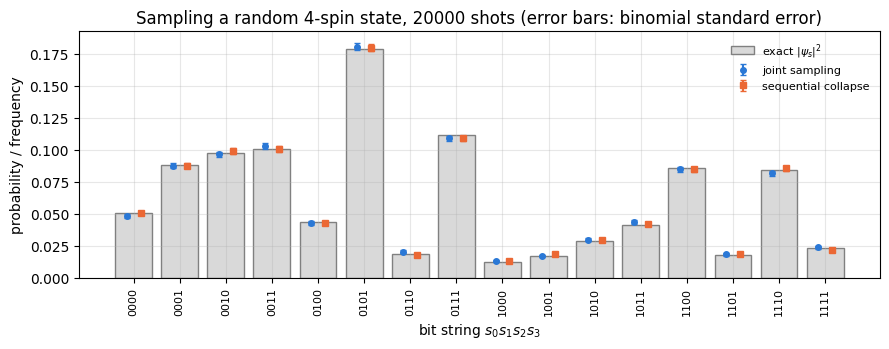

In [16]:
# ==============================================================================
# CHECKPOINT: both samplers reproduce |psi_s|^2 for a random 4-spin state (chi-squared test + figure)
# ==============================================================================
N, M = 4, 20000
psi = haar_state(jax.random.PRNGKey(4), N)
p_exact = np.abs(np.asarray(psi).reshape(-1)) ** 2


def histogram(bits):
    flat = np.asarray(bits) @ (2 ** np.arange(bits.shape[1] - 1, -1, -1))
    return np.bincount(flat, minlength=2 ** bits.shape[1])


n_joint = histogram(my_sample_bitstrings(jax.random.PRNGKey(10), psi, M))
n_seq = histogram(jax.jit(jax.vmap(lambda k: measure_all_sequential(k, psi)[0]))(jax.random.split(jax.random.PRNGKey(11), M)))
dof = 2 ** N - 1
for label, n in (("joint (categorical)", n_joint), ("sequential collapse", n_seq)):
    chi2 = np.sum((n - M * p_exact) ** 2 / (M * p_exact))
    print(f"{label:20s}: chi^2 = {chi2:6.2f}   (expected {dof} +- {np.sqrt(2 * dof):.1f})")
    assert chi2 < dof + 5 * np.sqrt(2 * dof)

labels = ["".join(map(str, b)) for b in itertools.product([0, 1], repeat=N)]
x = np.arange(2 ** N)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.bar(x, p_exact, width=0.8, color="0.85", edgecolor="0.5", label=r"exact $|\psi_s|^2$")
ax.errorbar(x - 0.15, n_joint / M, yerr=np.sqrt(p_exact * (1 - p_exact) / M), fmt="o", ms=4, capsize=2, color=PALETTE[0], label="joint sampling")
ax.errorbar(x + 0.15, n_seq / M, yerr=np.sqrt(p_exact * (1 - p_exact) / M), fmt="s", ms=4, capsize=2, color=PALETTE[1], label="sequential collapse")
ax.set_xticks(x); ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_xlabel(r"bit string $s_0s_1s_2s_3$"); ax.set_ylabel("probability / frequency")
ax.set_title(f"Sampling a random 4-spin state, {M} shots (error bars: binomial standard error)"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

Both $\chi^2$ values lie in the expected range $15\pm5.5$, and in the figure the sampled frequencies scatter around the exact probabilities by about one error bar, as they should. The two procedures are statistically equivalent;
they differ in cost (Section 14) and in what they return (the sequential one also gives the collapsed state, which matters when only *some* spins are measured).

The production version, with the optional per-spin bases:

In [17]:
# ==============================================================================
# Functions of quantum_engine.py derived in this notebook
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
SDG = S.conj().T

# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)


# ----------------------------------------------------------------------------
# 6. Measurements (Born rule, collapse, sampling)
# ----------------------------------------------------------------------------
_BASIS_ROT = {"Z": I2, "X": H, "Y": H @ SDG}  # U maps the eigenbasis of the Pauli to |0>,|1>:  P = U^dag Z U
def sample_bitstrings(key, psi, shots, bases=None):
    """Sample `shots` outcomes of measuring ALL qubits (no collapse bookkeeping needed).

    MATH   p(s) = |psi[s]|^2 ; optional per-qubit bases string like 'XZY' rotates first.
    IMPLEMENTATION   `jax.random.categorical` draws flat indices from log-probabilities; the bits are
    unpacked with shifts:  s_q = (i >> (N-1-q)) & 1   (qubit 0 = most significant bit).
    Returns an int array of shape (shots, N).
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, _BASIS_ROT[b], [q])
    logp = jnp.log(jnp.clip(jnp.abs(psi.reshape(-1)) ** 2, 1e-300, None))
    idx = jax.random.categorical(key, logp, shape=(shots,))
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


### 10.2 A cheaper sampler for many shots: the inverse CDF

The Gumbel-max trick spends $2^N$ random numbers *per shot*: for $N=12$ and $10^4$ shots that is $4\times10^7$ numbers and as many logarithms, and the memory grows as shots $\times\,2^N$.
The classic alternative is **inverse-transform sampling**: compute the cumulative distribution $c_i=\sum_{j\le i}p_j$ once ($O(2^N)$), draw *one* uniform number $u$ per shot and find the first index with $c_i>u$
by binary search (`jnp.searchsorted`, $O(N)$ per shot). Picture the interval $[0,1)$ cut into $2^N$ segments of lengths $p_i$: a uniformly thrown dart lands in segment $i$ with probability $p_i$.
We add this function in engine style (it is a candidate for the engine) and use it whenever we need very many shots.

In [18]:
# ==============================================================================
# STEP 6: inverse-CDF sampler -- O(2^N + shots * N) instead of O(shots * 2^N)
# ==============================================================================
def sample_bitstrings_cdf(key, psi, shots, bases=None):
    """Sample `shots` bit strings from |psi[s]|^2 by inverse-transform sampling.

    MATH            c_i = sum_{j<=i} p_j ;  u ~ U[0,1) ;  i = #{j : c_j <= u}   =>   P(i) = p_i
    IMPLEMENTATION  cumsum once, one uniform number per shot, binary search (`searchsorted`, side='right' so that
                    states with p_i = 0 are never returned); u is scaled by c_last to absorb rounding in the cumsum.
    COST            O(2^N + shots*N) time, O(2^N + shots) memory  (Gumbel-max `categorical`: O(shots * 2^N) both).
    JAX             `shots` fixes an array shape -> static under jit; psi and key are traced.
    """
    N = psi.ndim
    if bases is not None:
        for q, b in enumerate(bases):
            psi = apply_gate(psi, BASIS_ROT[b], [q])
    cdf = jnp.cumsum(jnp.abs(psi.reshape(-1)) ** 2)
    u = jax.random.uniform(key, (shots,), dtype=cdf.dtype) * cdf[-1]
    idx = jnp.clip(jnp.searchsorted(cdf, u, side="right"), 0, 2 ** N - 1)
    return (idx[:, None] >> jnp.arange(N - 1, -1, -1)[None, :]) & 1


n_cdf = histogram(sample_bitstrings_cdf(jax.random.PRNGKey(12), psi, M))
chi2 = np.sum((n_cdf - M * p_exact) ** 2 / (M * p_exact))
print(f"inverse-CDF sampler : chi^2 = {chi2:6.2f}   (expected {dof} +- {np.sqrt(2 * dof):.1f})")
assert chi2 < dof + 5 * np.sqrt(2 * dof)

# deterministic test with per-spin bases: |+>|0>|1>|r> read out in the bases X,Z,Z,Y must always give 0010
for sampler in (sample_bitstrings, sample_bitstrings_cdf):
    rec = sampler(jax.random.PRNGKey(3), product_state("+01r"), 500, bases="XZZY")
    print(f"{sampler.__name__:22s} on |+>|0>|1>|r> in bases XZZY: all records == 0010: {bool(jnp.all(rec == jnp.array([0, 0, 1, 0])))}")
    assert bool(jnp.all(rec == jnp.array([0, 0, 1, 0])))

# GHZ has zero-probability strings: they must never appear
rec = sample_bitstrings_cdf(jax.random.PRNGKey(5), ghz_state(10), 5000)
print("GHZ_10, 5000 shots (CDF sampler): distinct records =", sorted(set(bits_to_str(b) for b in np.asarray(rec))))

inverse-CDF sampler : chi^2 =  22.09   (expected 15 +- 5.5)


sample_bitstrings      on |+>|0>|1>|r> in bases XZZY: all records == 0010: True


sample_bitstrings_cdf  on |+>|0>|1>|r> in bases XZZY: all records == 0010: True


GHZ_10, 5000 shots (CDF sampler): distinct records = ['0000000000', '1111111111']


The inverse-CDF sampler passes the same $\chi^2$ test, handles per-spin bases, and returns no string of probability zero: if $p_i=0$ then $c_{i-1}=c_i$, the interval that would select $i$ is empty, and `side="right"`
makes the search land past it. The one loophole is the final `clip`, which is reached only when the rounded product $u\cdot c_{\rm last}$ comes out equal to $c_{\rm last}$ — a tie of probability $\lesssim2^{-53}$ per shot,
and the price for being safe against the cumsum ending a rounding unit below 1.

> **Physics insight.** Sampling *without collapsing* is a privilege of simulators: in the laboratory every shot destroys the state, which must be prepared again. In our functional code the state
> tensor `psi` is never modified by any of these functions, so "measuring" costs nothing in preparation — but keep the distinction in mind when you count experimental resources: **one shot = one state preparation**.

## 11. Shot noise: estimating expectation values with error bars

### 11.1 Estimators

Each shot in the $Z$ basis gives a string $s$; convert bits to eigenvalues $z_q=1-2s_q=\pm1$. Then

$$\widehat{\langle Z_q\rangle}=\frac1M\sum_{k=1}^Mz_q^{(k)},\qquad\widehat{\langle Z_iZ_j\rangle}=\frac1M\sum_kz_i^{(k)}z_j^{(k)} .$$

Both are sample means of a random variable $x=\pm1$ with mean $\mu=\langle O\rangle$ and variance $\sigma^2=\langle x^2\rangle-\mu^2=1-\langle O\rangle^2$. By the central limit theorem the estimate is
approximately Gaussian around the exact value with **standard error**

$$\mathrm{SE}=\frac{\sigma}{\sqrt M}=\sqrt{\frac{1-\langle O\rangle^2}{M}}\;\approx\;\frac{\text{sample std}}{\sqrt M}.$$

Three practical consequences: (i) one more digit costs $100\times$ more shots; (ii) the closer $|\langle O\rangle|$ is to 1, the smaller the noise (an eigenstate gives no noise at all); (iii) a result without an error bar is not a result.
$X$- or $Y$-type observables need shots taken in another basis setting (`bases="XX..X"`) — **each measurement setting costs its own shots**, because $X_q$ and $Z_q$ cannot be read in the same run.

### 11.2 Experiment: measuring the energy of a ground state the way a laboratory would

As a physically meaningful test state we take the ground state of the critical transverse-field Ising chain, $H=-J\sum_iZ_iZ_{i+1}-h\sum_iX_i$ with $J=h=1$ and $N=8$ (computed by the Lanczos
method of the engine, used as a black box and checked via the residual $\|H\psi-E\psi\|$). Its energy needs two settings: all spins in $Z$ for the bond terms, all spins in $X$ for the field terms.
For every shot we form the *single-shot energy contribution* $e^{ZZ}=-J\sum_iz_iz_{i+1}$ (or $e^X=-h\sum_ix_i$) and average afterwards. Summing first and averaging second is what makes the error bar right: the variance of a sum is

$$\mathrm{Var}\Big(\sum_ie_i\Big)=\sum_i\mathrm{Var}(e_i)+\sum_{i\ne j}\mathrm{Cov}(e_i,e_j),$$

and the bond terms $z_iz_{i+1}$ and $z_{i+1}z_{i+2}$ measured in the *same* shot are strongly correlated. For this ground state the covariances are positive and raise the variance of $e^{ZZ}$ by a factor $1.30$ over the sum of the individual
variances, so estimating each bond separately and adding the standard errors in quadrature would report an error bar $14\,\%$ too small. The sample standard deviation of the single-shot sum contains the covariances automatically.
Across the two settings the situation is different: they use different keys and different shots, so their covariance really is
zero and *their* errors do add in quadrature.

In [19]:
# ==============================================================================
# PARAMETERS
# ==============================================================================
N = 8                   # chain length
J_ISING, H_FIELD = 1.0, 1.0
N_SHOTS = 4000          # shots PER measurement setting

terms = heisenberg_terms(N, Jxx=0.0, Jyy=0.0, Jzz=-J_ISING, hx=-H_FIELD)
E0, psi_gs = lanczos_ground_state(terms, N, m=60, restarts=2)
residual = float(jnp.linalg.norm(apply_hamiltonian(terms, psi_gs) - E0 * psi_gs))
print(f"ground state: E0 = {E0:.8f},  residual |H psi - E psi| = {residual:.1e}")
assert residual < 1e4 * TOL


def mean_and_se(x):
    """Sample mean and its standard error  std/sqrt(M)  (ddof=1: unbiased variance estimate)."""
    x = np.asarray(x, dtype=float)
    return x.mean(), x.std(ddof=1) / np.sqrt(len(x))


key_z, key_x = jax.random.split(jax.random.PRNGKey(2024))
z = 1 - 2 * sample_bitstrings_cdf(key_z, psi_gs, N_SHOTS)                       # setting 1: all spins in Z   -> (M, N) of +-1
x = 1 - 2 * sample_bitstrings_cdf(key_x, psi_gs, N_SHOTS, bases="X" * N)       # setting 2: all spins in X

print(f"\n{'observable':>12s} {'estimate':>10s} {'std.err.':>9s} {'exact':>10s} {'deviation/SE':>13s}")
rows = [("<Z_3>", z[:, 3], expect_local(psi_gs, Z, (3,))), ("<X_3>", x[:, 3], expect_local(psi_gs, X, (3,))),
        ("<Z_3 Z_4>", z[:, 3] * z[:, 4], expect_local(psi_gs, ZZ, (3, 4))), ("<Z_0 Z_7>", z[:, 0] * z[:, 7], expect_local(psi_gs, ZZ, (0, 7))),
        ("<X_3 X_4>", x[:, 3] * x[:, 4], expect_local(psi_gs, XX, (3, 4)))]
for label, samples, exact in rows:
    est, se = mean_and_se(samples)
    print(f"{label:>12s} {est:+10.4f} {se:9.4f} {float(exact):+10.4f} {(est - float(exact)) / max(se, 1e-12):+13.2f}")
    assert abs(est - float(exact)) < 4 * se + 1e-12

e_zz = -J_ISING * jnp.sum(z[:, :-1] * z[:, 1:], axis=1)                          # single-shot bond energy (open chain)
e_x = -H_FIELD * jnp.sum(x, axis=1)                                              # single-shot field energy
(E_zz, se_zz), (E_x, se_x) = mean_and_se(e_zz), mean_and_se(e_x)
E_est, E_se = E_zz + E_x, np.sqrt(se_zz ** 2 + se_x ** 2)
print(f"\nenergy from 2 x {N_SHOTS} shots: E = {E_est:.3f} +- {E_se:.3f}    exact E0 = {E0:.3f}    deviation = {(E_est - E0) / E_se:+.2f} SE")
assert abs(E_est - E0) < 4 * E_se

ground state: E0 = -9.83795145,  residual |H psi - E psi| = 1.4e-14



  observable   estimate  std.err.      exact  deviation/SE


       <Z_3>    +0.0105    0.0158    -0.0000         +0.66
       <X_3>    +0.7005    0.0113    +0.6974         +0.28
   <Z_3 Z_4>    +0.5895    0.0128    +0.5787         +0.85
   <Z_0 Z_7>    +0.1400    0.0157    +0.1187         +1.36
   <X_3 X_4>    +0.6395    0.0122    +0.6448         -0.43



energy from 2 x 4000 shots: E = -9.870 +- 0.056    exact E0 = -9.838    deviation = -0.58 SE


Every estimate agrees with its exact value within a few standard errors (the `assert`s allow four). Note $\langle Z_3\rangle$: by the spin-flip symmetry of the Hamiltonian its exact value is 0, and the estimate is "zero within the error bar" — not zero.
The energy comes out with a relative error of a fraction of a percent after $8000$ state preparations. Because of the $1/\sqrt M$ law, a variational algorithm that needs the energy with a standard error of $10^{-2}$ at every optimisation step would need about 30 times more shots, and $10^{-3}$ about 3000 times more: this measurement overhead is a central practical issue of near-term quantum algorithms ([notebook 41, Chapter 11](../ch11_variational_quantum_circuits/41_optimizers.ipynb)).

### 11.3 The $1/\sqrt M$ law and the central limit theorem over $R=400$ repetitions

To *see* the statistics we repeat the whole experiment $R=400$ times for each number of shots $M$ — `vmap` over $R$ independent keys — and look at the distribution of the estimates of $\langle Z_3Z_4\rangle$:
its root-mean-square error against the exact value should follow $\sigma/\sqrt M$ with $\sigma=\sqrt{1-\langle Z_3Z_4\rangle^2}$ (no fit parameter), its histogram should be Gaussian, and the error bars
should "cover" the truth in about 68 % of the repetitions (one standard error) and 95 % (two).

exact <Z_3 Z_4> = 0.57870,  single-shot sigma = 0.8155
     M  rms error  sigma/sqrt(M)  ratio  within 1 SE  within 2 SE
    10    0.26373        0.25790   1.02         0.50         0.88
    30    0.14668        0.14890   0.99         0.64         0.97
   100    0.08178        0.08155   1.00         0.68         0.93
   300    0.04887        0.04709   1.04         0.66         0.94
  1000    0.02515        0.02579   0.98         0.65         0.96
  3000    0.01435        0.01489   0.96         0.71         0.95
 10000    0.00809        0.00816   0.99         0.66         0.97
 30000    0.00516        0.00471   1.10         0.64         0.94


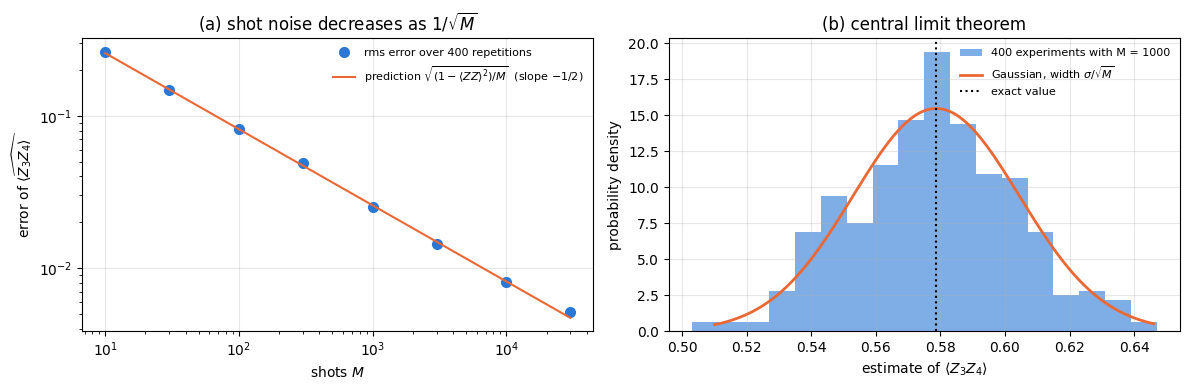

In [20]:
# ==============================================================================
# EXPERIMENT: R independent repetitions for each shot number M  (vmap over repetition keys)
# ==============================================================================
R = 400
SHOT_LIST = [10, 30, 100, 300, 1000, 3000, 10000, 30000]
exact = float(expect_local(psi_gs, ZZ, (3, 4)))
sigma = np.sqrt(1 - exact ** 2)


def one_experiment(key, shots):
    """One complete experiment: `shots` shots -> (estimate of <Z_3 Z_4>, its standard error)."""
    zz = 1 - 2 * sample_bitstrings_cdf(key, psi_gs, shots)
    v = (zz[:, 3] * zz[:, 4]).astype(RDTYPE)
    return jnp.mean(v), jnp.std(v, ddof=1) / jnp.sqrt(shots)


rms, cover1, cover2, estimates = [], [], [], {}
for i, M in enumerate(SHOT_LIST):
    rep_keys = jax.random.split(jax.random.PRNGKey(1000 + i), R)
    est, se = jax.jit(jax.vmap(partial(one_experiment, shots=M)))(rep_keys)       # shots is static: one compilation per M
    est, se = np.asarray(est), np.asarray(se)
    estimates[M] = est
    rms.append(np.sqrt(np.mean((est - exact) ** 2)))
    cover1.append(np.mean(np.abs(est - exact) < se)); cover2.append(np.mean(np.abs(est - exact) < 2 * se))
print(f"exact <Z_3 Z_4> = {exact:.5f},  single-shot sigma = {sigma:.4f}")
print(f"{'M':>6s} {'rms error':>10s} {'sigma/sqrt(M)':>14s} {'ratio':>6s} {'within 1 SE':>12s} {'within 2 SE':>12s}")
for M, r_, c1, c2 in zip(SHOT_LIST, rms, cover1, cover2):
    print(f"{M:6d} {r_:10.5f} {sigma / np.sqrt(M):14.5f} {r_ / (sigma / np.sqrt(M)):6.2f} {c1:12.2f} {c2:12.2f}")
ratio = np.array(rms) / (sigma / np.sqrt(np.array(SHOT_LIST)))
assert np.all(np.abs(ratio - 1) < 0.15), "rms error deviates from sigma/sqrt(M) by more than 15%"

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
ax.loglog(SHOT_LIST, rms, "o", color=PALETTE[0], ms=7, label=f"rms error over {R} repetitions")
ax.loglog(SHOT_LIST, sigma / np.sqrt(SHOT_LIST), "-", color=PALETTE[1], label=r"prediction $\sqrt{(1-\langle ZZ\rangle^2)/M}$  (slope $-1/2$)")
ax.set_xlabel("shots $M$"); ax.set_ylabel(r"error of $\widehat{\langle Z_3Z_4\rangle}$"); ax.set_title("(a) shot noise decreases as $1/\\sqrt{M}$"); ax.legend(fontsize=8)

ax = axes[1]
M_show = 1000
edges = -1 - 1 / M_show + (8 / M_show) * np.arange(2 * M_show)          # estimates live on a lattice of spacing 2/M: 4 lattice points per bin
edges = edges[(edges > estimates[M_show].min() - 8 / M_show) & (edges < estimates[M_show].max() + 8 / M_show)]
ax.hist(estimates[M_show], bins=edges, density=True, color=PALETTE[0], alpha=0.6, label=f"{R} experiments with M = {M_show}")
grid = np.linspace(estimates[M_show].min(), estimates[M_show].max(), 200)
s_ = sigma / np.sqrt(M_show)
ax.plot(grid, np.exp(-(grid - exact) ** 2 / (2 * s_ ** 2)) / np.sqrt(2 * np.pi * s_ ** 2), "-", color=PALETTE[1], lw=2, label=r"Gaussian, width $\sigma/\sqrt{M}$")
ax.axvline(exact, color="k", ls=":", label="exact value")
ax.set_xlabel(r"estimate of $\langle Z_3Z_4\rangle$"); ax.set_ylabel("probability density"); ax.set_title("(b) central limit theorem"); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

**(a)** Over three and a half decades of $M$ the measured rms error sits on the parameter-free line $\sigma/\sqrt M$ (ratios close to 1 in the table; they are themselves estimated from 400 repetitions and fluctuate by a few percent).
**(b)** The estimates are Gaussian distributed around the exact value with exactly that width. The coverage columns show that the *estimated* error bars cover the exact value at the stated rate: about two thirds of the experiments land within one standard error, about 95 % within two.
The one-standard-error column sits a little below the Gaussian $68.3\,\%$, and that is not a defect of the code: for a $\pm1$ observable the coverage can be computed exactly from the binomial distribution, and with $\langle Z_3Z_4\rangle=0.5787$ it is
$0.52$ at $M=10$, $0.62$ at $M=30$ and then $0.67$–$0.69$, approaching $0.683$ only slowly. Two effects push it down: the estimate lives on a lattice of spacing $2/M$, and the estimated error bar $\sqrt{(1-\widehat{\langle O\rangle}^2)/M}$ *shrinks*
exactly when the estimate wanders towards $\pm1$. At $M=10$ the last effect is extreme: all ten shots agree in 9 % of the experiments, and those get an error bar of zero, which can never cover anything.

> **Numerical practice.** For any stochastic estimate report *mean $\pm$ standard error*, check the $1/\sqrt M$ scaling once, and when comparing with a reference look at the deviation in units of the standard error.
> A deviation of $0.5\,$SE is not "better" than one of $1.5\,$SE; consistent deviations above $3\,$SE mean a bug or a bias.

## 12. A Bell pair measured along different axes

The cleanest demonstration that measurement outcomes on entangled spins are correlated *in every basis* — the raw material of Bell inequalities and quantum key distribution. For two spins define the correlation of outcomes

$$E(a,b)=\langle\sigma_a\otimes\sigma_b\rangle=P(\text{same})-P(\text{different}),$$

estimated from shots as the mean of $z_0z_1$ in the setting $(a,b)$. For $|\Phi^+\rangle=(|00\rangle+|11\rangle)/\sqrt2$ one finds $E(Z,Z)=+1$, $E(X,X)=+1$, $E(Y,Y)=-1$, and zero for all mixed settings;
for the singlet $|\Psi^-\rangle=(|01\rangle-|10\rangle)/\sqrt2$ the outcomes are perfectly **anti**-correlated in *every* common basis, $E(a,a)=-1$ — it is rotationally invariant (total spin zero).
Yet each spin alone is a fair coin in every basis ($\rho_q=\mathbb 1/2$). We first fill the $3\times3$ table from samples.

In [21]:
# ==============================================================================
# EXPERIMENT: 3x3 table of sampled Bell correlations E(a,b), 2000 shots per setting
# ==============================================================================
N_SHOTS = 2000
for kind in ("phi+", "psi-"):
    psi_bell = bell_state(kind)
    print(f"Bell state {kind}:   rows = basis of spin 0, columns = basis of spin 1;   entries: sampled E +- SE  [exact]")
    key = jax.random.PRNGKey(77 if kind == "phi+" else 78)
    for a in "XYZ":
        row = []
        for b in "XYZ":
            key, sub = jax.random.split(key)                       # a fresh key for every setting
            zz = 1 - 2 * sample_bitstrings(sub, psi_bell, N_SHOTS, bases=a + b)
            est, se = mean_and_se(zz[:, 0] * zz[:, 1])
            exact = float(expect_pauli_string(psi_bell, a + b))
            assert abs(est - exact) < 4 * se + 1e-12
            row.append(f"{est:+.3f}+-{se:.3f} [{exact:+.0f}]")
        print(f"   {a}:  " + "   ".join(row))
    single = 1 - 2 * sample_bitstrings(jax.random.PRNGKey(5), psi_bell, N_SHOTS, bases="XX")
    print(f"   single-spin average of spin 0 in the X basis: {mean_and_se(single[:, 0])[0]:+.3f} +- {mean_and_se(single[:, 0])[1]:.3f}  (a fair coin)\n")

Bell state phi+:   rows = basis of spin 0, columns = basis of spin 1;   entries: sampled E +- SE  [exact]


   X:  +1.000+-0.000 [+1]   +0.040+-0.022 [+0]   -0.034+-0.022 [+0]
   Y:  -0.016+-0.022 [+0]   -1.000+-0.000 [-1]   +0.018+-0.022 [+0]
   Z:  -0.021+-0.022 [+0]   +0.022+-0.022 [+0]   +1.000+-0.000 [+1]
   single-spin average of spin 0 in the X basis: +0.034 +- 0.022  (a fair coin)

Bell state psi-:   rows = basis of spin 0, columns = basis of spin 1;   entries: sampled E +- SE  [exact]
   X:  -1.000+-0.000 [-1]   +0.020+-0.022 [+0]   +0.015+-0.022 [+0]
   Y:  -0.030+-0.022 [+0]   -1.000+-0.000 [-1]   +0.010+-0.022 [+0]
   Z:  -0.043+-0.022 [+0]   -0.041+-0.022 [+0]   -1.000+-0.000 [-1]
   single-spin average of spin 0 in the X basis: -0.006 +- 0.022  (a fair coin)



The diagonal entries are *exactly* $\pm1$ with zero error bar: all 2000 shots agree (or all disagree) — perfect correlations have no shot noise. Mixed settings give zero within errors.

**Arbitrary axes.** Let spin 0 be measured along $z$ and spin 1 along the axis $\hat n(\theta)=(\sin\theta,0,\cos\theta)$ in the $x$–$z$ plane, i.e. the observable $\sigma_\theta=\cos\theta\,Z+\sin\theta\,X$. Since
$R_y(\theta)ZR_y(\theta)^\dagger=\cos\theta Z+\sin\theta X$, the rule of Section 6 applies with $U=R_y(\theta)^\dagger=R_y(-\theta)$: rotate spin 1 with $R_y(-\theta)$, then read out in $Z$. Quantum mechanics predicts

$$E(\theta)=\langle Z\otimes\sigma_\theta\rangle=\cos\theta\ \ (\Phi^+),\qquad E(\theta)=-\cos\theta\ \ (\Psi^-).$$

The angle is a *traced* number, so the whole scan over $\theta$ is one `vmap` (over angles and keys simultaneously).

CHECKPOINT Ry(t) Z Ry(t)^dag = cos(t) Z + sin(t) X : error = 1.1e-16


phi+: largest deviation from +cos(theta) = 2.73 standard errors


psi-: largest deviation from -cos(theta) = 2.46 standard errors


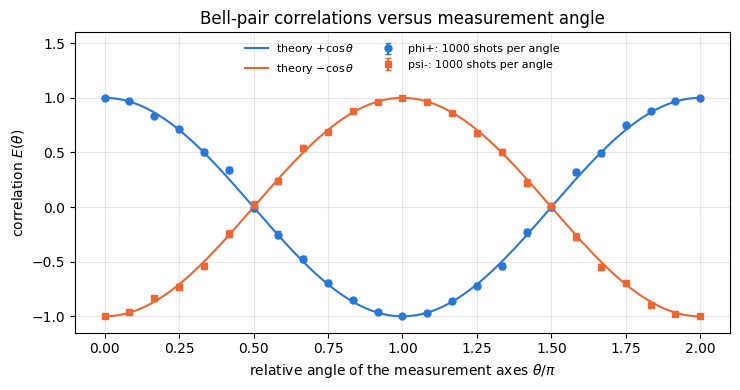

In [22]:
# ==============================================================================
# EXPERIMENT: E(theta) for phi+ and psi-, 1000 shots per angle, vmapped over the angles
# ==============================================================================
theta_test = 0.7
err = max_abs(ry(theta_test) @ Z @ ry(theta_test).conj().T - (np.cos(theta_test) * Z + np.sin(theta_test) * X))
print(f"CHECKPOINT Ry(t) Z Ry(t)^dag = cos(t) Z + sin(t) X : error = {err:.1e}")
assert err < TOL

N_SHOTS, N_ANGLES = 1000, 25
thetas = jnp.linspace(0.0, 2 * jnp.pi, N_ANGLES)


def correlation_at_angle(theta, key, psi):
    """Sampled E(theta) +- SE: spin 0 along z, spin 1 along (sin t, 0, cos t)."""
    rotated = apply_gate(psi, ry(-theta), [1])                     # U = Ry(theta)^dagger on spin 1, then Z readout
    zz = 1 - 2 * sample_bitstrings(key, rotated, N_SHOTS)
    v = (zz[:, 0] * zz[:, 1]).astype(RDTYPE)
    return jnp.mean(v), jnp.std(v, ddof=1) / jnp.sqrt(N_SHOTS)


fig, ax = plt.subplots(figsize=(7.5, 4))
fine = np.linspace(0, 2 * np.pi, 300)
for kind, sign, c, m in (("phi+", +1, PALETTE[0], "o"), ("psi-", -1, PALETTE[1], "s")):
    keys = jax.random.split(jax.random.PRNGKey(31 if sign > 0 else 32), N_ANGLES)
    E, SE = jax.jit(jax.vmap(partial(correlation_at_angle, psi=bell_state(kind))))(thetas, keys)
    E, SE = np.asarray(E), np.asarray(SE)
    pull = (E - sign * np.cos(np.asarray(thetas))) / np.maximum(SE, 1e-3)
    print(f"{kind}: largest deviation from {'+' if sign > 0 else '-'}cos(theta) = {np.max(np.abs(pull)):.2f} standard errors")
    assert np.max(np.abs(pull)) < 4.5
    ax.plot(fine / np.pi, sign * np.cos(fine), "-", color=c, lw=1.5, label=rf"theory ${'+' if sign > 0 else '-'}\cos\theta$")
    ax.errorbar(np.asarray(thetas) / np.pi, E, yerr=SE, fmt=m, color=c, ms=5, capsize=2, label=f"{kind}: {N_SHOTS} shots per angle")
ax.set_xlabel(r"relative angle of the measurement axes $\theta/\pi$"); ax.set_ylabel(r"correlation $E(\theta)$")
ax.set_title("Bell-pair correlations versus measurement angle"); ax.legend(fontsize=8, ncol=2, loc="upper center")
ax.set_ylim(-1.15, 1.6)
fig.tight_layout(); plt.show()

The sampled correlations follow $\pm\cos\theta$ within their error bars; note how the error bars shrink to zero where $|E|=1$ and are largest ($1/\sqrt M\approx0.03$) where $E=0$ — the $\sqrt{1-E^2}$ law of Section 11.
The smooth cosine is what makes quantum correlations stronger than any classical "hidden instruction set" could produce: such models are constrained by the CHSH inequality $|S|\le2$, while four well-chosen angles on this curve give $2\sqrt2$.
The derivation and a sample-based CHSH test are the subject of [notebook 19, Chapter 8](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb) (and of Exercise 6).

## 13. Measurements inside compiled loops: mid-circuit measurement

So far a measurement ended the story. In many protocols it sits *in the middle* of the dynamics and is repeated many times. The JAX pattern is `lax.scan` (notebook 01): the loop body is compiled once; the **carry** holds the
state (and any classical memory), and the **scanned input is an array of keys**, one per round, prepared beforehand with `jax.random.split`. `vmap` over a second batch of keys then runs many independent realisations in parallel.

### 13.1 The quantum Zeno effect

A spin starts in $|0\rangle$ and is rotated about $x$ by a total angle $\pi$, which would take it to $|1\rangle$ with certainty. Now split the rotation into $n$ equal steps $R_x(\pi/n)$ and measure $Z$ after each step.
After one small step the probability to still find $0$ is $\cos^2(\pi/2n)$, and if we do, the state is *reset to $|0\rangle$ by the collapse*. The probability of finding 0 in **all** $n$ measurements is therefore

$$P_{\rm survive}(n)=\Big[\cos^2\frac{\pi}{2n}\Big]^n .$$

Taking the logarithm, $\ln P_{\rm survive}=2n\ln\cos(\pi/2n)=-n\big[(\pi/2n)^2+O(n^{-4})\big]$, so

$$P_{\rm survive}(n)=\exp\Big(-\frac{\pi^2}{4n}+O(n^{-3})\Big)=1-\frac{\pi^2}{4n}+O(n^{-2})\;\longrightarrow\;1 .$$

A watched spin does not flip: frequent measurement freezes the dynamics, and the deficit closes like $1/n$. The reason is that for short times transition probabilities grow *quadratically*, $\sin^2(\epsilon/2)\approx\epsilon^2/4$,
so $n$ interruptions cost only $n\cdot(\pi/2n)^2=\pi^2/4n\to0$ instead of the $O(1)$ they would cost if the probability grew linearly in time. Per unit of the swept angle the effective flip rate therefore vanishes as $1/n$.

   n    P_survive (sampled)   theory  deviation/SE
   1       0.0000 +- 0.0000   0.0000         -0.00
   2       0.2620 +- 0.0070   0.2500         +1.73
   4       0.5220 +- 0.0079   0.5308         -1.11
   8       0.7238 +- 0.0071   0.7331         -1.33
  16       0.8600 +- 0.0055   0.8569         +0.57
  32       0.9280 +- 0.0041   0.9258         +0.55
  64       0.9663 +- 0.0029   0.9622         +1.43
 128       0.9793 +- 0.0023   0.9809         -0.74


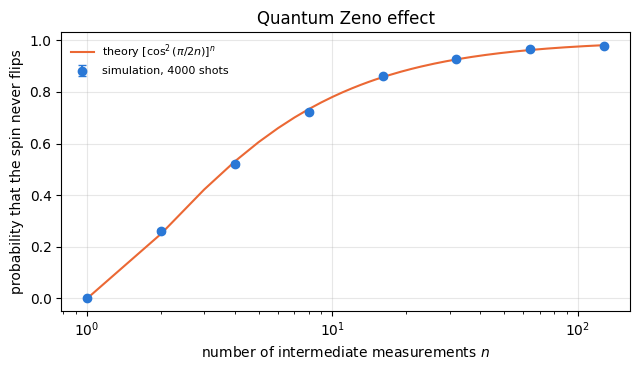

In [23]:
# ==============================================================================
# EXPERIMENT: quantum Zeno effect -- scan over measurement rounds, vmap over shots
# ==============================================================================
N_SHOTS = 4000


def zeno_shot(key, n_steps):
    """One realisation: n_steps x [rotate by pi/n_steps about x, measure Z]. Returns True if ALL outcomes were 0."""
    U = rx(jnp.pi / n_steps)

    def one_round(carry, round_key):
        psi, survived = carry
        psi = apply_gate(psi, U, [0])                              # coherent evolution
        outcome, psi = measure_qubit(round_key, psi, 0)            # mid-circuit measurement (branch-free -> scan-able)
        return (psi, survived & (outcome == 0)), outcome

    round_keys = jax.random.split(key, n_steps)                    # one key per round, prepared up front
    (_, survived), _ = lax.scan(one_round, (zero_state(1), jnp.array(True)), round_keys)
    return survived


steps = [1, 2, 4, 8, 16, 32, 64, 128]
P_hat, P_se = [], []
for n in steps:
    shots = jax.jit(jax.vmap(partial(zeno_shot, n_steps=n)))(jax.random.split(jax.random.PRNGKey(n), N_SHOTS))
    p = float(jnp.mean(shots)); P_hat.append(p); P_se.append(np.sqrt(max(p * (1 - p), 1e-12) / N_SHOTS))
P_hat, P_se = np.array(P_hat), np.array(P_se)
P_theory = np.cos(np.pi / (2 * np.array(steps))) ** (2 * np.array(steps))
print(f"{'n':>4s} {'P_survive (sampled)':>22s} {'theory':>8s} {'deviation/SE':>13s}")
for n, p, s, t in zip(steps, P_hat, P_se, P_theory):
    print(f"{n:4d} {p:12.4f} +- {s:.4f} {t:8.4f} {(p - t) / max(s, 1e-6):+13.2f}")
assert np.all(np.abs(P_hat - P_theory) < 4 * P_se + 1e-9)

fig, ax = plt.subplots(figsize=(6.5, 3.8))
nn = np.arange(1, 129)
ax.semilogx(nn, np.cos(np.pi / (2 * nn)) ** (2 * nn), "-", color=PALETTE[1], label=r"theory $[\cos^2(\pi/2n)]^n$")
ax.errorbar(steps, P_hat, yerr=P_se, fmt="o", color=PALETTE[0], capsize=3, label=f"simulation, {N_SHOTS} shots")
ax.set_xlabel("number of intermediate measurements $n$"); ax.set_ylabel("probability that the spin never flips")
ax.set_title("Quantum Zeno effect"); ax.legend(fontsize=8); fig.tight_layout(); plt.show()

With a single final measurement ($n=1$) the spin has always flipped ($P=0$, with no shot noise at all); with 128 interruptions it survives in about 98 % of the runs, in agreement with the formula for every $n$.
Technically, each point is one compiled program containing a `scan` over $n$ rounds inside a `vmap` over 4000 shots — $5\times10^5$ simulated measurements for $n=128$, and no Python loop over either.

### 13.2 Entanglement *created* by measurement

Section 9 showed measurements destroying entanglement. They can also **create** it between spins that never interacted directly. Take the 1D cluster state of notebook 06 ($|{+}\rangle^{\otimes N}$ followed by controlled-$Z$ on every bond). Its stabilisers
connect a site only to its neighbours, and in fact **no pair of its spins is entangled at all**: every two-spin reduced state is separable, either exactly $\mathbb 1/4$ in the bulk or, at the two ends of the open chain, the classically correlated
$\rho_{01}=(\mathbb 1+X_0Z_1)/4$ and $\rho_{N-2,N-1}=(\mathbb 1+Z_{N-2}X_{N-1})/4$ that the end stabilisers $X_0Z_1$ and $Z_{N-2}X_{N-1}$ produce. The entanglement of the cluster state is genuinely multipartite, which is exactly why measurements can
concentrate it into a pair. Its two end spins in particular are **not entangled with each other**: for $N\ge4$ their reduced state is $\mathbb 1/4$ (no correlations whatsoever), and for $N=3$ it is the classical mixture
$\tfrac12(|{+}{+}\rangle\langle{+}{+}|+|{-}{-}\rangle\langle{-}{-}|)=(\mathbb 1+X_0X_2)/4$ — correlated in $X$, but separable (the code below checks both statements). Now measure all *interior* spins in the $X$ basis. For $N=3$ the argument is short: the state is stabilised by $K_0=X_0Z_1$, $K_1=Z_0X_1Z_2$, $K_2=Z_1X_2$
(eigenvalue $+1$ each). The products $K_0K_2=X_0X_2$ and $K_1$ commute with the measured $X_1$, so they remain valid after the measurement, with $X_1$ replaced by its outcome $(-1)^m$:
the ends are left in the state with $X_0X_2=+1$ and $Z_0Z_2=(-1)^m$ — a Bell state, $|\Phi^+\rangle$ or $|\Psi^+\rangle$ depending on the outcome. Measuring the middle spin in $Z$ instead *cuts* the chain and leaves a product state.
This is the elementary step of measurement-based quantum computing and of entanglement swapping in quantum repeaters.

In [24]:
# ==============================================================================
# EXPERIMENT: measure the interior of a cluster chain; entanglement between the two END spins
# ==============================================================================
def measure_interior(key, N, basis):
    """Measure spins 1..N-2 of the N-spin cluster state in `basis`; return outcomes, S(end spin), <X_0 X_{N-1}>, <Z_0 Z_{N-1}>."""
    psi = cluster_state(N)
    keys = jax.random.split(key, N)
    outs = []
    for q in range(1, N - 1):
        m, psi = measure_qubit(keys[q], psi, q, basis)
        outs.append(m)
    ends = {0: "X", N - 1: "X"}, {0: "Z", N - 1: "Z"}
    return jnp.stack(outs), entanglement_entropy(psi, (0,)), expect_pauli_string(psi, ends[0]), expect_pauli_string(psi, ends[1])


keys = jax.random.split(jax.random.PRNGKey(9), 1000)
rho_ends_3 = rdm(cluster_state(3), (0, 2))
rho_ends_7 = rdm(cluster_state(7), (0, 6))
print(f"before any measurement, N = 3: |rho_ends - (1 + X0 X2)/4| = {max_abs(rho_ends_3 - (jnp.eye(4) + XX) / 4):.1e}   (a classical mixture of |++> and |-->)")
print(f"before any measurement, N = 7: |rho_ends - 1/4|           = {max_abs(rho_ends_7 - jnp.eye(4) / 4):.1e}   (no correlations at all)\n")
assert max_abs(rho_ends_3 - (jnp.eye(4) + XX) / 4) < TOL and max_abs(rho_ends_7 - jnp.eye(4) / 4) < TOL
for N_c, basis in ((3, "X"), (3, "Z"), (7, "X")):
    outs, S_end, xx, zz = jax.jit(jax.vmap(partial(measure_interior, N=N_c, basis=basis)))(keys)
    outs, S_end, xx, zz = map(np.asarray, (outs, S_end, xx, zz))
    print(f"N = {N_c}, interior measured in {basis}:  S(end spin | record) min/max over 1000 shots = {S_end.min():.6f} / {S_end.max():.6f} bits")
    if N_c == 3:
        for m in (0, 1):
            sel = outs[:, 0] == m
            print(f"      outcome {m} ({sel.mean():.3f} of the shots):  <X_0 X_2> = {xx[sel].mean():+.3f},  <Z_0 Z_2> = {zz[sel].mean():+.3f}")
        print(f"      averaged over outcomes (record discarded):  <X_0 X_2> = {xx.mean():+.3f},  <Z_0 Z_2> = {zz.mean():+.3f}")
    if basis == "X":
        assert abs(S_end.min() - 1) < 1e3 * TOL and abs(S_end.max() - 1) < 1e3 * TOL
    else:
        assert S_end.max() < 1e3 * TOL

before any measurement, N = 3: |rho_ends - (1 + X0 X2)/4| = 1.1e-16   (a classical mixture of |++> and |-->)
before any measurement, N = 7: |rho_ends - 1/4|           = 2.2e-16   (no correlations at all)



N = 3, interior measured in X:  S(end spin | record) min/max over 1000 shots = 1.000000 / 1.000000 bits
      outcome 0 (0.498 of the shots):  <X_0 X_2> = +1.000,  <Z_0 Z_2> = +1.000
      outcome 1 (0.502 of the shots):  <X_0 X_2> = +1.000,  <Z_0 Z_2> = -1.000
      averaged over outcomes (record discarded):  <X_0 X_2> = +1.000,  <Z_0 Z_2> = -0.004


N = 3, interior measured in Z:  S(end spin | record) min/max over 1000 shots = 0.000000 / 0.000000 bits
      outcome 0 (0.498 of the shots):  <X_0 X_2> = +1.000,  <Z_0 Z_2> = +0.000
      outcome 1 (0.502 of the shots):  <X_0 X_2> = +1.000,  <Z_0 Z_2> = +0.000
      averaged over outcomes (record discarded):  <X_0 X_2> = +1.000,  <Z_0 Z_2> = +0.000


N = 7, interior measured in X:  S(end spin | record) min/max over 1000 shots = 1.000000 / 1.000000 bits


* $X$ measurements: in **every** shot the end spins share exactly 1 bit of entanglement — for $N=3$ and also for $N=7$, where the two ends are six sites apart and five spins were measured. For $N=3$ the correlations are $X_0X_2=+1$ and
  $Z_0Z_2=(-1)^m$, as derived.
* $Z$ measurement: the ends are left in a product state ($S=0$). The printed $\langle X_0X_2\rangle=+1$ is not a leftover of entanglement but a classical correlation: $K_0=X_0Z_1$ and $K_2=Z_1X_2$ both commute with the measured $Z_1$, so the
  outcome fixes $X_0=X_2=(-1)^m$ separately on each end, and the state is the product $|x_0\rangle|z_1\rangle|x_2\rangle$.
* If the record is discarded, $\langle Z_0Z_2\rangle$ averages to zero (within shot noise): the entanglement is only *useful* together with the classical outcome. Turning "a random one of several Bell states" into "always $|\Phi^+\rangle$" requires a correction conditioned on the outcome — feedback,
  exactly as in `reset_qubit`, and exactly as in quantum teleportation ([notebook 20, Chapter 8](../ch08_quantum_information_protocols/20_quantum_teleportation.ipynb)).

## 14. Performance

How expensive is randomness? We time (i) single-spin measurement shots at $N=12$: a Python loop over a jitted single-shot function versus one `jit(vmap(...))` call; and (ii) a complete readout at $N=12$: sequential collapse versus
`categorical` (Gumbel-max) versus the inverse CDF. Timing rules as always: block until the result is ready; the first call includes compilation and is reported separately.

| method | time per batch | memory |
|---|---|---|
| `measure_qubit`, $M$ shots (vmap) | $O(M\,2^N)$ | $O(M\,2^N)$ — the batch of post-measurement states |
| full readout, sequential | $O(M\,N\,2^N)$ | $O(M\,2^N)$ |
| full readout, `categorical` | $O(M\,2^N)$ random numbers | $O(M\,2^N)$ |
| full readout, inverse CDF | $O(2^N+M\,N)$ | $O(2^N+M)$ |

In [25]:
# ==============================================================================
# BENCHMARK at N = 12
# ==============================================================================
def timed(fn, *args, repeats=3):
    """(first call incl. compilation, best of `repeats` further calls) in seconds."""
    t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); first = time.perf_counter() - t0
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter(); jax.block_until_ready(fn(*args)); best = min(best, time.perf_counter() - t0)
    return first, best


N, M = 12, 1000
psi = haar_state(jax.random.PRNGKey(0), N)
keys = jax.random.split(jax.random.PRNGKey(1), M)

# (i) single-spin measurement: python loop over shots vs vmap
single = jax.jit(lambda k: measure_qubit(k, psi, 0))                          # returns (outcome, post-measurement state)
batched = jax.jit(jax.vmap(lambda k: measure_qubit(k, psi, 0)))
jax.block_until_ready(single(keys[0]))                                        # compile
t0 = time.perf_counter()
for k in keys[:200]:                                                          # 200 shots, one Python iteration each
    jax.block_until_ready(single(k))
t_loop = (time.perf_counter() - t0) / 200
first, t_vmap = timed(batched, keys)
print(f"measure_qubit, N={N}:  python loop {t_loop * 1e6:9.1f} us/shot  |  jit(vmap) {t_vmap / M * 1e6:9.1f} us/shot"
      f"  (compile {first:.2f} s)  ->  speed-up x{t_loop / (t_vmap / M):.0f}")

# (ii) complete readout, three ways
print(f"\ncomplete readout of N={N} spins:")
print(f"{'method':>24s} {'shots':>7s} {'first call [s]':>15s} {'run [ms]':>10s} {'us/shot':>9s}")
for shots in (1000, 10000):
    ks = jax.random.split(jax.random.PRNGKey(2), shots)
    methods = {"sequential collapse": (jax.jit(jax.vmap(lambda k: measure_all_sequential(k, psi)[0])), (ks,)),
               "categorical (Gumbel-max)": (jax.jit(partial(sample_bitstrings, shots=shots)), (ks[0], psi)),
               "inverse CDF": (jax.jit(partial(sample_bitstrings_cdf, shots=shots)), (ks[0], psi))}
    for name, (fn, args) in methods.items():
        if name.startswith("sequential") and shots > 1000:
            continue                                                          # 10^4 x 2^12 post-states: skip to stay in budget
        first, run = timed(fn, *args, repeats=2)
        print(f"{name:>24s} {shots:7d} {first:15.2f} {run * 1e3:10.2f} {run / shots * 1e6:9.2f}")

measure_qubit, N=12:  python loop    2185.3 us/shot  |  jit(vmap)      73.9 us/shot  (compile 0.35 s)  ->  speed-up x30

complete readout of N=12 spins:
                  method   shots  first call [s]   run [ms]   us/shot


     sequential collapse    1000            4.20    1769.29   1769.29


categorical (Gumbel-max)    1000            0.42      67.04     67.04


             inverse CDF    1000            0.28       0.23      0.23


categorical (Gumbel-max)   10000            1.59     867.72     86.77


             inverse CDF   10000            0.52       0.88      0.09


**Interpreting the benchmark** (absolute numbers depend on the machine and its load; look at the ratios).

* Batching the shots with `vmap` is one to two orders of magnitude faster per shot than calling a jitted single-shot function from a Python loop: the loop pays the Python-side dispatch of one XLA program per shot, and a batch of 1000 shots keeps
  the machine busy where a single $2^{12}$ tensor does not. Real analysis code is slower still, because inspecting the outcome with `int(...)` adds a device-to-host transfer per shot.
* For a complete readout the three samplers differ by orders of magnitude, in the order predicted by the cost table: the sequential collapse does $N$ projections of the full state per shot, the Gumbel-max sampler generates $2^N$ random numbers per shot,
  and the inverse CDF needs one random number and an $N$-step binary search per shot after a single pass over the state.
* Rule of thumb: use `sample_bitstrings` for moderate `shots`$\times2^N$; switch to the inverse CDF for many shots or larger $N$; use sequential `measure_qubit` only when you need the *post-measurement state* (partial or mid-circuit measurements).

## 15. Key takeaways

* **Born rule on a subsystem** = diagonal of its reduced density matrix; **collapse** = `apply_gate` with a $2\times2$ projector on one axis + renormalisation. Cost $O(2^N)$, no large matrices.
* Other bases: **rotate – measure $Z$ – rotate back** ($U=H$ for $X$, $U=HS^\dagger$ for $Y$, $U=R_y(-\theta)$ for an axis in the $x$–$z$ plane).
* Stochastic JAX code: explicit keys (split, never reuse), **no Python `if` on random values** — select with `jnp.where`; then `jit`, `vmap` (shots) and `lax.scan` (repeated rounds) just work. Feedback (reset, corrections) is the same trick.
* Measuring part of an entangled state changes the rest: GHZ is destroyed by one $Z$ measurement, W mostly survives; an unread measurement is dephasing; reset is the channel $\rho\to|0\rangle\langle0|\otimes\mathrm{Tr}_q\rho$; $X$ measurements on a cluster chain create a Bell pair between its ends.
* A complete readout can be sampled jointly from $|\psi_s|^2$ (chain rule $\Rightarrow$ same statistics as sequential collapse). Know the cost of your sampler: Gumbel-max $O(\text{shots}\times2^N)$, inverse CDF $O(2^N+\text{shots}\times N)$.
* **Shot noise**: standard error $\sqrt{(1-\langle O\rangle^2)/M}$; every measurement setting needs its own shots; always report mean $\pm$ SE and validate stochastic code with $z$-scores and $\chi^2$, not with `TOL`.
* Frequent measurements freeze dynamics (Zeno); measurement + classical record + feedback is a universal primitive of quantum protocols.

## 16. Exercises

1. ★ **By-hand einsum.** For $N=4$ write the einsum strings that give $p(m)$ for spin $q=2$ and the projected state for outcome $m=1$. Check against `rdm` and `apply_gate` with `assert max_abs(...) < TOL`.
2. ★ **Expectation value from single-spin shots.** Using `vmap` over `measure_qubit`, estimate $\langle Y_0\rangle$ with its standard error for the state `product_state("r0")` rotated by `apply_gate(psi, rx(0.4), [0])`. Compare with `expect_local`;
   the exact answer is $\cos(0.4)=0.92106$. Why would `ry(0.4)` instead of `rx(0.4)` make the exercise pointless?
3. ★★ **Measuring an arbitrary single-spin observable (extend the code).** Write `measure_observable(key, psi, q, O)` for any Hermitian $2\times2$ matrix $O$: diagonalise $O=V\,\mathrm{diag}(\lambda_0,\lambda_1)V^\dagger$ with `jnp.linalg.eigh`, use $U=V^\dagger$ as the basis rotation, and return the
   *eigenvalue* and the post-measurement state. Verify with $O=(X+Z)/\sqrt2$ on $|0\rangle$: the mean of the returned eigenvalues must approach $\langle O\rangle=1/\sqrt2$. Why does this work under `jit` although `eigh` is called inside?
4. ★★ **Measurements on a density tensor (extend the code).** Write `measure_qubit_dm(key, rho, q)` for a rank-$2N$ density tensor: $p(0)=\mathrm{Tr}(P_0\rho_q)$ from `rdm_dm`-style contraction (or from the diagonal), collapse $\rho\to\Pi_m\rho\Pi_m/p(m)$ with two `apply_gate` calls.
   Check on `to_dm(psi)` that, for the same key, it reproduces `to_dm` of the pure-state result.
5. ★★ **Shot budget (physics/practice).** For the ground state of Section 11 estimate, using the single-shot variances measured there, how many shots per setting are needed to obtain the energy per site with a standard error of $10^{-3}$. Verify by simulation.
   Would it be better to distribute the shots unequally between the two settings? (Minimise $\sigma_{ZZ}^2/M_{ZZ}+\sigma_X^2/M_X$ at fixed $M_{ZZ}+M_X$.)
6. ★★ **CHSH from samples (physics).** With `correlation_at_angle`-style code estimate $S=E(a,b)+E(a,b')+E(a',b)-E(a',b')$ for $|\Phi^+\rangle$ with spin 0 measured along angles $a=0$, $a'=\pi/2$ and spin 1 along $b=\pi/4$, $b'=-\pi/4$ (you need a rotation on spin 0 as well).
   Propagate the four standard errors. How many shots per setting are needed to violate $|S|\le2$ by five standard errors?
7. ★★★ **Zeno with a general measurement rate (extend the code).** Modify `zeno_shot` so that in each round the measurement happens only with probability $p$ (draw a second random number per round and select between the measured and the unmeasured state with `jnp.where` — think about how to do this for a state *tensor*).
   Plot the probability to find the spin in $|0\rangle$ at the end (not the survival of the whole record) versus $p$ for $n=64$ rounds.
8. ★★★ **Measurement-induced disentangling in a many-body state (physics).** Take a Haar-random state of $N=10$ spins (volume-law entanglement, notebook 06). Measure a fraction $f$ of randomly chosen spins in $Z$ and compute the average half-chain entanglement entropy *of the post-measurement state*
   as a function of $f$ (average over shots and over the choice of spins with `vmap`; the measured positions must be static, so loop over a few random choices). Compare with the same experiment on the cluster state and on GHZ.

## References

* M. A. Nielsen and I. L. Chuang, *Quantum Computation and Quantum Information* (Cambridge University Press, 2000) — measurement postulate and projective measurements (Sec. 2.2), principle of deferred/implicit measurement (Sec. 4.4).
* J. J. Sakurai and J. Napolitano, *Modern Quantum Mechanics*, 3rd ed. (Cambridge University Press, 2020) — measurement, spin-1/2 and Stern–Gerlach sequences (Ch. 1, *Fundamental Concepts*), spin correlation measurements and Bell's inequality (Ch. 3, *Theory of Angular Momentum*).
* J. S. Bell, *On the Einstein Podolsky Rosen paradox*, Physics **1**, 195 (1964); J. F. Clauser, M. A. Horne, A. Shimony, R. A. Holt, *Proposed experiment to test local hidden-variable theories*, Phys. Rev. Lett. **23**, 880 (1969).
* B. Misra and E. C. G. Sudarshan, *The Zeno's paradox in quantum theory*, J. Math. Phys. **18**, 756 (1977); W. M. Itano, D. J. Heinzen, J. J. Bollinger, D. J. Wineland, *Quantum Zeno effect*, Phys. Rev. A **41**, 2295 (1990).
* W. Dür, G. Vidal, J. I. Cirac, *Three qubits can be entangled in two inequivalent ways*, Phys. Rev. A **62**, 062314 (2000) — robustness of W versus GHZ.
* H. J. Briegel and R. Raussendorf, *Persistent entanglement in arrays of interacting particles*, Phys. Rev. Lett. **86**, 910 (2001); R. Raussendorf and H. J. Briegel, *A one-way quantum computer*, Phys. Rev. Lett. **86**, 5188 (2001).
* E. J. Gumbel, *Statistics of Extremes* (Columbia University Press, 1958) — the distribution behind the Gumbel-max trick; L. Devroye, *Non-Uniform Random Variate Generation* (Springer, 1986) — inverse-transform sampling.
* W. H. Press, S. A. Teukolsky, W. T. Vetterling and B. P. Flannery, *Numerical Recipes: The Art of Scientific Computing*, 3rd ed. (Cambridge University Press, 2007) — Section 7.3 (*Deviates from Other Distributions*: the transformation
  and inverse-CDF methods used in Section 10.2) and Section 14.3 (*Are Two Distributions Different?*: the $\chi^2$ test and its degrees of freedom); the same algorithms in *Numerical Recipes in Fortran 90*, 2nd ed. (Cambridge University Press, 1996).
* JAX documentation, *Pseudorandom numbers* (https://docs.jax.dev) — design of the explicit-key PRNG.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/